In [113]:
import pandas as pd
import glob
import os
import scanpy as sc

In [114]:
from IPython.display import HTML, display
from cellphonedb.utils import db_releases_utils

display(HTML(db_releases_utils.get_remote_database_versions_html()['db_releases_html_table']))

In [3]:
sc.settings.figdir = "fig5"


In [4]:
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(20,20))


In [5]:
os.getcwd()

'/nfs/users/nfs_l/ls34/CCC_Analyses'

In [115]:
cpdb_version = 'v5.0.0'

# -- Path where the input files to generate the database are located
cpdb_target_dir = os.path.join('/nfs/team298/ls34/wound/cellphonedb/', cpdb_version)

In [116]:
from cellphonedb.utils import db_utils

db_utils.download_database(cpdb_target_dir, cpdb_version)

Downloaded cellphonedb.zip into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded complex_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded gene_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded interaction_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded protein_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0
Downloaded uniprot_synonyms.tsv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0/sources
Downloaded transcription_factor_input.csv into /nfs/team298/ls34/wound/cellphonedb/v5.0.0/sources


In [8]:
0

0

In [117]:
cpdb_input_dir = '/nfs/team298/ls34/wound/cellphonedb/v5.0.0/'


In [118]:
from cellphonedb.utils import db_utils

# -- Creates new database
db_utils.create_db(cpdb_input_dir)


Created /nfs/team298/ls34/wound/cellphonedb/v5.0.0/cellphonedb_10_05_2025_132821.zip successfully


In [11]:
# %%bash

# mv /nfs/team298/ls34/cellphonedb/v5.0.0/cellphonedb_09_28_2024_123936.zip /nfs/team298/ls34/cellphonedb/v5.0.0/cellphonedb.zip

In [12]:
pd.set_option('display.max_columns', 100)

In [13]:
os.listdir(cpdb_target_dir)

['complex_input.csv',
 'cellphonedb_04_24_2025_144353.zip',
 'cellphonedb_07_13_2025_093414.zip',
 'cellphonedb_04_18_2025_084606.zip',
 'cellphonedb_07_12_2025_192405.zip',
 'cellphonedb_07_13_2025_093659.zip',
 'cellphonedb_07_12_2025_164300.zip',
 'results',
 'gene_input.csv',
 'cellphonedb_07_12_2025_165925.zip',
 'cellphonedb_04_18_2025_085909.zip',
 'cellphonedb_04_20_2025_184622.zip',
 'cellphonedb.zip',
 'cellphonedb_02_11_2025_113059.zip',
 'cellphonedb_04_22_2025_143422.zip',
 'cellphonedb_07_12_2025_165926.zip',
 'sources',
 'interaction_input.csv',
 'cellphonedb_07_13_2025_132659.zip',
 'cellphonedb_09_24_2025_092100.zip',
 'cellphonedb_02_11_2025_120244.zip',
 'cellphonedb_10_05_2025_110658.zip',
 'cellphonedb_07_12_2025_163222.zip',
 'cellphonedb_04_24_2025_100903.zip',
 'cellphonedb_04_24_2025_151255.zip',
 'cellphonedb_07_12_2025_192132.zip',
 'cellphonedb_10_03_2025_164440.zip',
 'cellphonedb_10_05_2025_105120.zip',
 'cellphonedb_04_18_2025_081529.zip',
 'cellphonedb_0

In [119]:
cpdb_file_path = os.path.join(cpdb_target_dir, 'cellphonedb.zip')
cpdb_file_path




'/nfs/team298/ls34/wound/cellphonedb/v5.0.0/cellphonedb.zip'

In [120]:
meta_file_path ='/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_sebo.tsv'

In [121]:
out_path = '/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore'


In [122]:
metadata = pd.read_csv(meta_file_path, sep = '\t')
metadata.head(3)

,barcode_sample,cell_type
0,GCGCGATGTGGAAAGA_GSM3717037,KC_HF_ORS0
1,CTCGTACAGCATGGCA_S4,Treg
2,CATATGGGTCCGAATT_P2,Treg


In [18]:
metadata.cell_type.value_counts()

cell_type
Th                                2140
LC                                1118
Treg_LRRC32+                      1092
cDC2: EREG+CCR7+                   967
cDC2                               815
Tnaive                             762
cDC2: MMP12hi                      734
T                                  729
Treg                               721
TRM_IL13+                          719
cDC1                               668
KC_HF: ORS0                        565
KC_Sebocyte_DuctOuter              424
KC_Sebocyte_DuctInner              341
ILC3                               341
MigDC (cDC2)                       306
ILC1                               253
pDC                                 74
ILC2                                55
TRM_IL17+                           53
KC_Sebocyte_DuctInner_Junction      45
T_Prolif                            35
ILC3_CCL1+PTGDS+                    31
Name: count, dtype: int64

In [123]:
import anndata
#counts_file_path = '/nfs/team298/ls34/new_disease_atlas/model_scanvi5_v3skin_ADPSonly_clean_5941/ccc/normalised_log_counts_all_sebo.h5ad'
counts_file_path='/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_sebo.h5ad'
adata = anndata.read_h5ad(counts_file_path)
adata.shape

(12988, 32732)

In [21]:
# KEEP_LIST = [#'Melanocyte',
#  #'KC3',
#  #'Sweat gland',
#  'Pericyte1_CCL19+_signalling',
#  'VE3_SELPhi',
#  'LE',
#  #'Sweat gland channel inner',
#  'VE1_ADAMTS6hi',
#  'F3: CCL19+',
#  'cDC1',
#  'Pericyte2_CASQ2_Muscle',
#  #'Sweat gland channel outer',
#  'nmSchwann',
#  'Mac2',
#  'F2/3: Bridge',
#  'F1: Superficial',
#  'LC',
#  'F2: Universal',
#  'F5: NGFR+',
#  'cDC2: IL1B+',
# # 'F4: TNN+COCH+',
#  'F1: Superficial regenerative',
#  #'Cartilage',
#  'cDC2: MMP12+',
#  #'KC_HF/SC: LGR6+ACTA2+',
#  'F5: RAMP1+',
#  'MigDC',
# # 'F4: DS_DPEP1+',
#  #'mSchwann',
#  #'KC1',
#  'ILC1_3',
#  'Plasma cell',
#  'MoDC',
#  'F6: Myofibroblast inflammatory',
#  #'pDC',
#  'Tc_IFNGhi',
#  #'Smooth muscle',
#  #'Bcell',
#  'Tc_IL13',
#  #'F4: DP_HHIP+',
#  'Treg',
#  'ILC2_inflammatory',
#  'Th',
#  'Tc',
# # 'KC_Sebocyte_basal',
# # 'KC_Sebocyte_inner',
#  'VE2',
#  #'Mono',
#  #'MacTREM2_CX3CR1+',
#  'NK',
#  'ILC1_NK',
#  'Tc_gamma_delta',
#  'Tr1',
#  'Mast cell',
#  'Tnaive/Tcm',
#  #'KC4',
#  #'KC2/3_cycling',
#  #'KC2',
#  #'KCinflamm_basal',
#  #'KCinflamm_int',
#  #'KC5',
#  'ILC2',
#  #'KC_HF: ORS/CL',
#  #'KC_HF: Basal_LGR5+',
#  #'F_Fascia',
#  #'Merkel cell',
#  #'KC_HF: Basal_NPNT+',
#  #'Mono CD16+',
#  #'KC_HF: IRS+HS',
#  'Mac1',
#  #'KCinflamm_late',
#  #'KCinflamm_cycling',
#  'Tc_IL17',
#  #'Satellite muscle',
#  #'Adipocyte',
#  #'Neutrophil',
#  #'Skeletal muscle'
# ]
# KEEP_LIST

In [22]:
0

0

In [124]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
    #active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
    #microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 5,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.05,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = out_path,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

Reading user files...
The following user files were loaded successfully:
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/normalised_log_counts_all_sebo.h5ad
/nfs/team298/ls34/adult_skin/cellphonedb/input_files/metadata_all_sebo.tsv
[ ][CORE][05/10/25-13:28:33][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][05/10/25-13:28:33][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][05/10/25-13:28:34][INFO] Running Real Analysis
[ ][CORE][05/10/25-13:28:34][INFO] Running Statistical Analysis


100%|██████████| 1000/1000 [03:22<00:00,  4.94it/s]


[ ][CORE][05/10/25-13:31:57][INFO] Building Pvalues result
[ ][CORE][05/10/25-13:31:59][INFO] Building results
[ ][CORE][05/10/25-13:31:59][INFO] Scoring interactions: Filtering genes per cell type..


100%|██████████| 23/23 [00:00<00:00, 94.47it/s]

[ ][CORE][05/10/25-13:31:59][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|██████████| 23/23 [00:00<00:00, 275.69it/s]


[ ][CORE][05/10/25-13:32:00][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████| 529/529 [02:10<00:00,  4.06it/s]


Saved deconvoluted to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_10_05_2025_133415.txt
Saved deconvoluted_percents to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_percents_10_05_2025_133415.txt
Saved means to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_10_05_2025_133415.txt
Saved pvalues to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_10_05_2025_133415.txt
Saved significant_means to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_significant_means_10_05_2025_133415.txt
Saved interaction_scores to /nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_10_05_2025_133415.txt


# analysis

In [24]:
1

1

In [125]:
import os
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

In [126]:
import os
os.listdir('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/')

['statistical_analysis_interaction_scores_04_27_2025_102032.txt',
 'statistical_analysis_significant_means_07_14_2025_150347.txt',
 'statistical_analysis_interaction_scores_02_11_2025_164652.txt',
 'statistical_analysis_interaction_scores_07_13_2025_151857.txt',
 'statistical_analysis_deconvoluted_10_05_2025_111229.txt',
 'statistical_analysis_means_07_20_2025_120846.txt',
 'statistical_analysis_deconvoluted_05_19_2025_161057.txt',
 'statistical_analysis_means_04_27_2025_102032.txt',
 'statistical_analysis_means_02_11_2025_200835.txt',
 'statistical_analysis_pvalues_07_13_2025_144935.txt',
 'statistical_analysis_means_04_24_2025_103010.txt',
 'statistical_analysis_significant_means_02_11_2025_133108.txt',
 'statistical_analysis_significant_means_09_23_2025_152529.txt',
 'statistical_analysis_deconvoluted_07_20_2025_120846.txt',
 'statistical_analysis_pvalues_09_24_2025_093053.txt',
 'statistical_analysis_pvalues_04_21_2025_202321.txt',
 'statistical_analysis_significant_means_02_11_202

In [27]:
adata.obs

,sample_id,barcode,GSE,Site_status,Patient_status,Location,Age,Sex,n_genes,dataset_id,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,QC_hi,QC_mid,lvl5_annotation,Mapping_status,scanvi_predictions,lvl5_annotation_new,lvl5_annotation_new2,lvl5_annotation_new3,lvl5_annotation_new_archive,lvl5_annotation_new_preoprhan,lvl5_annotation_new10,lvl5_annotation_new11,test,test_n,lvl5_annotation_new12,lvl5_annotation_new13,lvl4_annotation,lvl0,temp,t,leiden_res0.1,Site_status_simple,StatusMilo,atlas_status,atlas_status_reynolds,atlas_status_reynolds_simple,atlas_status_simple,atlas_status_simple2,Site_status_binary,lvl1_new,provisional_celltypes
GCGCGATGTGGAAAGA_GSM3717037,GSM3717037,GCGCGATGTGGAAAGA,Takahashi,Nonlesional,Healthy,scalp,nan,Male,2217,Takahashi,2217,8994.0,38.981543,55.514788,67.200356,78.029798,225.0,2.501668,3781.0,42.039137,Pass_hi,Pass_mid,KC_HF: ORS0,atlas,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0_n=10288,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_Appendage,NaN,other,7,Nonlesional,Healthy_Nonlesional_Takahashi,Nonlesional atlas,Nonlesional atlas,Nonlesional atlas,NaN,Nonlesional,Nonlesional,KC_HF,KC_HF: ORS0
CTCGTACAGCATGGCA_S4,SKN8104902,CTCGTACAGCATGGCA,Reynolds,Nonlesional,Healthy,Breast,Reyn_missing,Female,1224,Reynolds,1224,2447.0,30.200245,41.356763,52.921945,70.412750,62.0,2.533715,510.0,20.841847,Pass_hi,Pass_mid,Treg,atlas,Treg,Treg,Treg,Treg,Treg,Treg,Treg,Treg,Other,Other_n=1755295,Treg,Treg,Treg,T,NaN,other,8,Nonlesional,Healthy_Nonlesional_Reynolds,Nonlesional atlas,Nonlesional atlas,Nonlesional atlas,NaN,Nonlesional,Nonlesional,T,Treg
CATATGGGTCCGAATT_P2,SKN8090588,CATATGGGTCCGAATT,Reynolds,Lesional,Psoriasis,Lower_back,Reyn_missing,Male,590,Reynolds,590,1670.0,48.143713,64.550898,76.646707,94.610778,5.0,0.299401,833.0,49.880240,Low total count,Pass_mid,Treg,atlas,Treg,Treg,Treg,Treg,Treg,Treg,Treg,Treg,Other,Other_n=1755295,Treg,Treg,Treg,T,NaN,other,8,Lesional,Psoriasis_Lesional_Reynolds,Psoriasis_Lesional_Reynolds,Psoriasis_Lesional_Reynolds,Psoriasis_Lesional_Reynolds,Psoriasis_Lesional,Psoriasis_Lesional,Lesional,T,Treg
TTTACTGCACCGTCGA-1sample5-Rojahn,AD6,TTTACTGCACCGTCGA,Rojahn et al.,Lesional,AD,Rojahn et al.,Rojahn et al.,Rojahn et al.,1226,Rojahn_AD,1226,3624.0,41.363135,55.684327,66.639073,79.966887,273.0,7.533113,952.0,26.269316,Pass_hi,Pass_mid,cDC2: MMP12hi,atlas,cDC2: MMP12hi,cDC2: MMP12hi,cDC2: MMP12hi,cDC2: MMP12hi,cDC2: MMP12hi,cDC2: MMP12hi,cDC2: MMP12hi,cDC2: MMP12hi,Other,Other_n=1755295,cDC2: MMP12hi,cDC2: MMP12hi,cDC2: MMP12hi,Myeloid,NaN,other,5,Lesional,Eczema_Lesional_Rojahn_AD,Eczema_Lesional_Rojahn,Eczema_Lesional_Other,Other_Eczema/Psoriasis,Eczema_Lesional,Eczema_Lesional,Lesional,Myeloid,cDC2: MMP12hi
CTCGTCACATAGAAAC_SRS9768411,SRS9768411,CTCGTCACATAGAAAC,PRJNA754272,Nonlesional,Healthy,Limb,75,F,803,Ahlers_Dermalsheath,803,1926.0,40.186916,53.271028,66.458982,84.267913,50.0,2.596054,441.0,22.897196,Low total count,Pass_mid,cDC2,atlas,cDC2,cDC2,cDC2,cDC2,cDC2,cDC2,cDC2,cDC2,Other,Other_n=1755295,cDC2,cDC2,cDC2,Myeloid,NaN,other,5,Nonlesional,Healthy_Nonlesional_Ahlers_Dermalsheath,Nonlesional atlas,Nonlesional atlas,Nonlesional atlas,NaN,Nonlesional,Nonlesional,Myeloid,cDC2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CCTTCGAGTTGAGGTG_GSM3717037,GSM3717037,CCTTCGAGTTGAGGTG,Takahashi,Nonlesional,Healthy,scalp,nan,Male,2322,Takahashi,2322,9000.0,37.866667,53.311111,64.288889,76.022222,183.0,2.033333,3589.0,39.877778,Pass_hi,Pass_mid,KC_HF: ORS0,atlas,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0,KC_HF: ORS0_n=10288,KC_HF: ORS

In [28]:
# cpdb_results

In [127]:
try:
    decon=cpdb_results['deconvoluted']
    deconv=cpdb_results['deconvoluted']
    means = cpdb_results['means']
    pvals = cpdb_results['pvalues']
    interaction_scores=cpdb_results['interaction_scores']
    print("instantantiated")
except:
    print("not loaded")
    
    deconv = pd.read_csv("/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_percents_04_21_2025_202321.txt",  sep="\t")
    #means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_04_21_2025_202321.txt', sep="\t")
    means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_significant_means_04_21_2025_202321.txt', sep="\t")
    pvals = pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_04_21_2025_202321.txt", sep="\t")
    interaction_scores=pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_04_21_2025_202321.txt", sep="\t")
    import anndata
    counts_file_path = '/nfs/team298/ls34/wound/cellphonedb/input_files/normalised_log_counts.h5ad'
    adata = anndata.read_h5ad(counts_file_path)
    adata.shape
    
 # statistical_analysis_deconvoluted_percents_10_09_2024_201259.txt
#5.2M -rw-r--r-- 1 ls34 team298  21M Oct  9 20:13 
#1.8M -rw-r--r-- 1 ls34 team298  19M Oct  9 20:13 
#768K -rw-r--r-- 1 ls34 team298 5.2M Oct  9 20:13 statistical_analysis_significant_means_10_09_2024_201259.txt
 

instantantiated


In [30]:
#  statistical_analysis_deconvoluted_04_21_2025_202321.txt
# 960K -rw-r--r-- 1 ls34 team298  4.2M Apr 21 20:23 .txt
#  33M -rw-r--r-- 1 ls34 team298  112M Apr 21 20:23 .txt
# 9.4M -rw-r--r-- 1 ls34 team298   95M Apr 21 20:23 .txt
# 3.5M -rw-r--r-- 1 ls34 team298   26M Apr 21 20:24 statistical_analysis_significant_means_04_21_2025_202321.txt
#  40K drwxr-sr-x 2 ls34 team298  5.7K Apr 21 20:24 .
#  12M -rw-r--r-- 1 ls34 team298   a95M Apr 21 20:25 statistical_analysis_interaction_scores_04_21_2025_202321.txt
# ls34@node-13-15:~$ 

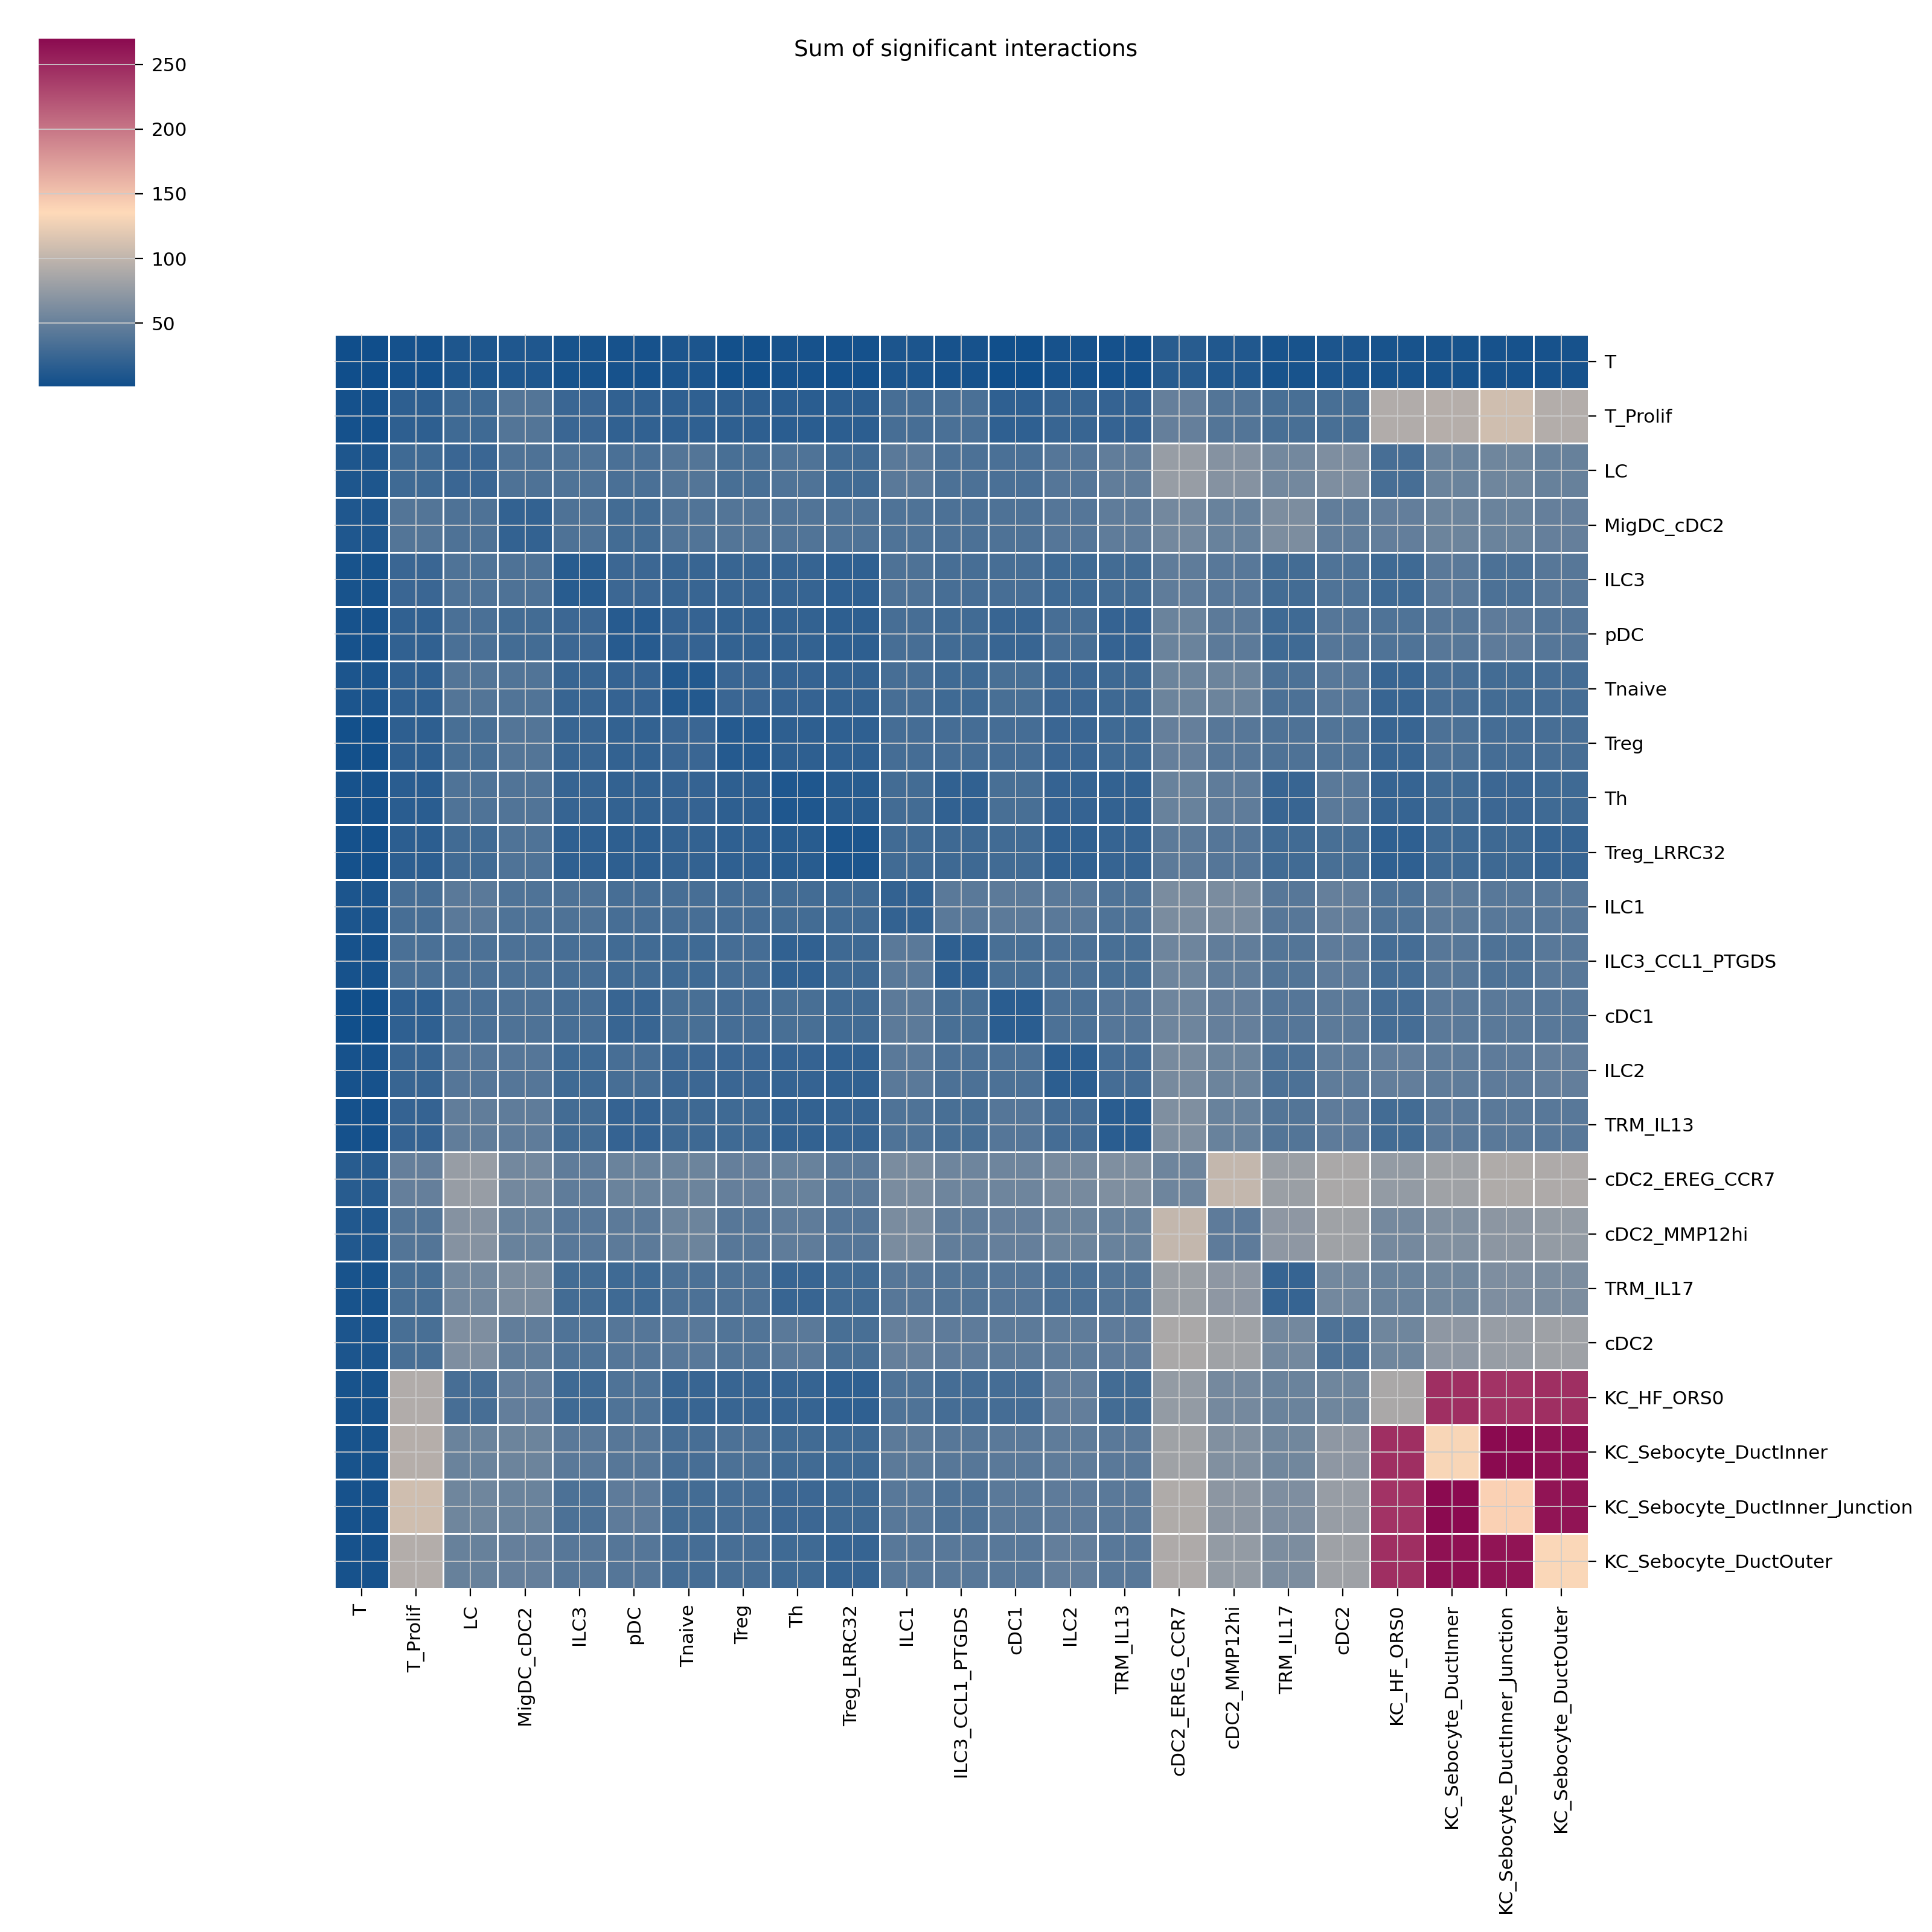

In [128]:
try:
    kpy.plot_cpdb_heatmap(pvals = pvals,
                      degs_analysis = False,
                      figsize = (20,20),
                      title = "Sum of significant interactions")
except:
    1

In [32]:
kpy.plot_cpdb_heatmap(
    pvals=pvals, cell_types=["MigDC", "Tnaive/Tcm",], figsize=(4, 4), title="Sum of significant interactions"
)

UnboundLocalError: cannot access local variable 'count_mat' where it is not associated with a value

In [ ]:
# kpy.plot_cpdb(
#     adata = adata,
#     cell_type1 = "PV MYH11|PV STEAP4|PV MMPP11",
#     cell_type2 = "EVT_1|EVT_2|GC|iEVT|eEVT|VCT_CCC",
#     means = cpdb_results['means'],
#     pvals = cpdb_results['pvalues'],
#     celltype_key = "cell_labels",
#     genes = ["TGFB2", "CSF1R"],
#     figsize = (10, 3),
#     title = "Interactions between\nPV and trophoblast",
#     max_size = 3,
#     highlight_size = 0.75,
#     degs_analysis = False,
#     standard_scale = True,
#     interaction_scores = cpdb_results['interaction_scores'],
#     scale_alpha_by_interaction_scores = True
# )

In [ ]:
KEEP = adata.obs["lvl5_annotation"].unique()
KEEP =  "|".join(KEEP)
KEEP

In [ ]:
means

In [ ]:
interaction_scores.head(10)

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 =  "TRM_IL17+", # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = "cDC2",
    #['Sweat gland', "Sweat gland channel outer", "Sweat gland channel inner", "pDC", "F2/3: Perivascular",
                         # "Pericyte1", "VE4_cap", "VE3_Prolif_APLN+", "pDC_LAMP5+"
                             # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Bcell', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = "Sweat gland Myoepithelial",     # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results = search_results[search_results["significant_mean"] > 0.0]

search_results.tail(60)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['MigDC', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results = search_results[search_results["interacting_cells"].str.startswith("pDC")]
search_results = search_results[search_results["significant_mean"] > 0.1]

search_results.tail(60)



In [33]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = 'MigDC (cDC2)',  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = "TRM_IL13+",     # List of cells 2, will be paired to cells 1 (list or 'All').
 # genes ="TNFRSF13C|TNFRSF13B|CCR6|CXCR5",# "CD27", "CD22", "COL19A1", #"ITGA10",
     #"ITGB1", 
    # "FCER2",# "FGFR2", 
    # "COL19A1",#"CDH2",
                                      # filter interactions based on the genes participating (list).
  # query_interactions = ['TNFSF13B_TNFRSF13C'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 10,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

#search_results = search_results[search_results["significant_mean"] > 0.0]

search_results.head(60)



,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [34]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Bcell', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
 # genes ="TNFRSF13C|TNFRSF13B|CCR6|CXCR5",# "CD27", "CD22", "COL19A1", #"ITGA10",
     #"ITGB1", 
    # "FCER2",# "FGFR2", 
    # "COL19A1",#"CDH2",
                                      # filter interactions based on the genes participating (list).
   query_interactions = ['TNFSF13B_TNFRSF13C'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results = search_results[search_results["significant_mean"] > 0.3]

search_results.head(60)



,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [ ]:
search_results["interacting_pair"].unique()

In [ ]:
['CD48_CD244', 'PTPRC_CD22', 'COL19A1_integrin_a2b1_complex',
       'FCER2_FGFR2', 'FCER2_integrin_aXb2_complex', 'CD70_CD27',
       'TNFSF13B_TNFRSF13B', 'TNFSF13B_TNFRSF13C', 'CXCL13_CXCR5'],

In [ ]:
import inspect

print(inspect.signature(kpy.plot_cpdb))

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Bcell",
    cell_type2=KEEP,
    #   query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'AD
   # AM12', "ACHE",
    #       "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
    genes=  ["CD48", "CD244", "CD70", "CD27", "CD22", "COL19A1", #"ITGA10",
     #"ITGB1", 
     "FCER2",# "FGFR2", 
     "COL19A1",#"CDH2",
     "CXCR5", ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(12, 8),
)


# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = adata.obs["lvl5_annotation"].unique(),  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#                                        # filter interactions based on the genes participating (list).
#  #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
#     significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
#     deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
#     query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results.head(50)



In [35]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="TRM_IL13",
    cell_type2="cDC2",
    #   query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'AD
   # AM12', "ACHE",
    #       "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
   # genes=  ["TNFRSF13C", "TNFRSF13B", "CCR6",# "CD27", "CD22", "COL19A1", #"ITGA10",
     #"ITGB1", 
    # "FCER2",# "FGFR2", 
    # "COL19A1",#"CDH2",
   #  "CXCR5", ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(12, 8),
)
 


KeyboardInterrupt



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="TRM_IL13",
    cell_type2= "MigDC (cDC2)",
    #genes = [  "CCL17", "CCL22", "CCL19"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(15, 15),
    min_interaction_score=2,
    scale_alpha_by_interaction_scores=True,
    alpha=0.05
)

In [ ]:

from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['TRM_IL13', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ["MigDC (cDC2)"],     # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)


In [36]:
KEEP = adata.obs["lvl5_annotation"].unique()
KEEP =  "|".join(KEEP)
KEEP

'KC_HF: ORS0|Treg|cDC2: MMP12hi|cDC2|Th|MigDC (cDC2)|Tnaive|cDC1|TRM_IL13+|Treg_LRRC32+|KC_Sebocyte_DuctOuter|ILC3|cDC2: EREG+CCR7+|KC_Sebocyte_DuctInner|LC|ILC2|T|ILC1|T_Prolif|TRM_IL17+|pDC|ILC3_CCL1+PTGDS+|KC_Sebocyte_DuctInner_Junction'

In [ ]:
      # List of cells 2, will be paired to cells 1 (list or 'All').


In [46]:

from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Treg|cDC2: MMP12hi|cDC2|Th|MigDC (cDC2)|Tnaive|cDC1|TRM_IL13+|Treg_LRRC32+ILC3|cDC2: EREG+CCR7+LC|ILC2|T|ILC1|T_Prolif|TRM_IL17+|pDC|ILC3_CCL1+PTGDS+'],  # List of cells 1, will be paired to cells 2 (list or 'All').
    #query_cell_types_2 =  adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
     query_cell_types_2 =  ['KC_Sebocyte_DuctOuter|KC_Sebocyte_DuctInner|KC_Sebocyte_DuctInner_Junction|KC_HF: ORS0'],
     #    query_cell_types_2 =  ['KC2/3_cycling', 'KC_Sebocyte_duct_inner', 'cDC2',
     #                       'LC', 'cDC2: MMP12hi', 'KC_Sebocyte_duct_basal/outer',
     #                       'KCinflamm_basal', 'cDC1',
     #                       'KC_HF: ORS 1/2', 'MigDC (cDC2)', 'MigDC (cDC1)'],
    #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 1,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)
#search_results=search_results[search_results["significant_mean"]>.2]
search_results.head(50)


,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean
89,AREG_EGFR,simple:P15514,simple:P00533,AREG,EGFR,Ligand-Receptor,Signaling by Epidermal growth factor,ILC1|KC_HF: ORS0,1.342
255,CD44_TYROBP,simple:P16070,simple:O43914,CD44,TYROBP,Ligand-Receptor,NaN,ILC1|KC_HF: ORS0,1.160
264,PPIA_BSG,simple:P62937,simple:P35613,PPIA,BSG,Ligand-Receptor,NaN,ILC1|KC_HF: ORS0,1.212
355,AREG_EGFR,simple:P15514,simple:P00533,AREG,EGFR,Ligand-Receptor,Signaling by Epidermal growth factor,ILC1|KC_Sebocyte_DuctInner,1.278
530,PPIA_BSG,simple:P62937,simple:P35613,PPIA,BSG,Ligand-Receptor,NaN,ILC1|KC_Sebocyte_DuctInner,1.271
621,AREG_EGFR,simple:P15514,simple:P00533,AREG,EGFR,Ligand-Receptor,Signaling by Epidermal growth factor,ILC1|KC_Sebocyte_DuctInner_Junction,1.152
787,CD44_TYROBP,simple:P16070,simple:O43914,CD44,TYROBP,Ligand-Receptor,NaN,ILC1|KC_Sebocyte_DuctInner_Junction,1.198
796,PPIA_BSG,simple:P62937,simple:P35613,PPIA,BSG,Ligand-Receptor,NaN,ILC1|KC_Sebocyte_DuctInner_Junction,1.295
887,AREG_EGFR,simple:P15514,simple:P00533,AREG,EGFR,Ligand-Receptor,Signaling by Epidermal growth factor,ILC1|KC_Sebocyte_DuctOuter,1.309
1053,CD44_TYROBP,simple:P16070,simple:O43914,CD44,TYROBP,Ligand-Receptor,NaN,ILC1|KC_Sebocyte_DuctOuter,1.160


In [47]:

from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Treg',
                          'cDC2: MMP12hi',
                          'cDC2',
                          'Th',
                          'MigDC (cDC2)',
                          'Tnaive',
                          'cDC1','TRM_IL13+',
                          'Treg_LRRC32+',
                          'ILC3',
                          'cDC2: EREG+CCR7+',
                          'LC', 'ILC2', 'ILC1', 'TRM_IL17+','pDC','ILC3_CCL1+PTGDS+'],  # List of cells 1, will be paired to cells 2 (list or 'All').
    #query_cell_types_2 =  adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
     query_cell_types_2 =  ['KC_Sebocyte_DuctOuter', 'KC_Sebocyte_DuctInner', 'KC_Sebocyte_DuctInner_Junction', 'KC_HF: ORS0'],
     #    query_cell_types_2 =  ['KC2/3_cycling', 'KC_Sebocyte_duct_inner', 'cDC2',
     #                       'LC', 'cDC2: MMP12hi', 'KC_Sebocyte_duct_basal/outer',
     #                       'KCinflamm_basal', 'cDC1',
     #                       'KC_HF: ORS 1/2', 'MigDC (cDC2)', 'MigDC (cDC1)'],
    
    #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 1,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)
search_results=search_results[search_results["significant_mean"]>1]
search_results.head(50)


,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean
89,AREG_EGFR,simple:P15514,simple:P00533,AREG,EGFR,Ligand-Receptor,Signaling by Epidermal growth factor,ILC1|KC_HF: ORS0,1.342
255,CD44_TYROBP,simple:P16070,simple:O43914,CD44,TYROBP,Ligand-Receptor,NaN,ILC1|KC_HF: ORS0,1.160
264,PPIA_BSG,simple:P62937,simple:P35613,PPIA,BSG,Ligand-Receptor,NaN,ILC1|KC_HF: ORS0,1.212
355,AREG_EGFR,simple:P15514,simple:P00533,AREG,EGFR,Ligand-Receptor,Signaling by Epidermal growth factor,ILC1|KC_Sebocyte_DuctInner,1.278
530,PPIA_BSG,simple:P62937,simple:P35613,PPIA,BSG,Ligand-Receptor,NaN,ILC1|KC_Sebocyte_DuctInner,1.271
621,AREG_EGFR,simple:P15514,simple:P00533,AREG,EGFR,Ligand-Receptor,Signaling by Epidermal growth factor,ILC1|KC_Sebocyte_DuctInner_Junction,1.152
787,CD44_TYROBP,simple:P16070,simple:O43914,CD44,TYROBP,Ligand-Receptor,NaN,ILC1|KC_Sebocyte_DuctInner_Junction,1.198
796,PPIA_BSG,simple:P62937,simple:P35613,PPIA,BSG,Ligand-Receptor,NaN,ILC1|KC_Sebocyte_DuctInner_Junction,1.295
887,AREG_EGFR,simple:P15514,simple:P00533,AREG,EGFR,Ligand-Receptor,Signaling by Epidermal growth factor,ILC1|KC_Sebocyte_DuctOuter,1.309
1053,CD44_TYROBP,simple:P16070,simple:O43914,CD44,TYROBP,Ligand-Receptor,NaN,ILC1|KC_Sebocyte_DuctOuter,1.160


In [86]:
#genes_list = 

from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Treg',
                          'cDC2: MMP12hi',
                          'cDC2',
                          'Th',
                          'MigDC (cDC2)',
                          'Tnaive',
                          'cDC1','TRM_IL13+',
                          'Treg_LRRC32+',
                          'ILC3',
                          'cDC2: EREG+CCR7+',
                          'LC', 'ILC2', 'ILC1', 'TRM_IL17+','pDC','ILC3_CCL1+PTGDS+'],  # List of cells 1, will be paired to cells 2 (list or 'All').
    #query_cell_types_2 =  adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
     query_cell_types_2 =  ['KC_Sebocyte_DuctOuter', 'KC_Sebocyte_DuctInner', 'KC_Sebocyte_DuctInner_Junction', 'KC_HF: ORS0'],
     #    query_cell_types_2 =  ['KC2/3_cycling', 'KC_Sebocyte_duct_inner', 'cDC2',
     #                       'LC', 'cDC2: MMP12hi', 'KC_Sebocyte_duct_basal/outer',
     #                       'KCinflamm_basal', 'cDC1',
     #                       'KC_HF: ORS 1/2', 'MigDC (cDC2)', 'MigDC (cDC1)']
    #query_genes = [ "CCL19"],                                      # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 1,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)
search_results=search_results[search_results["significant_mean"]>.1]
#search_results.head(50)
search_results["interacting_pair"].unique()

array(['COL21A1_integrin_a2b1_complex', 'COL9A2_integrin_a2b1_complex',
       'CADM1_CADM1', 'CRTAM_CADM1', 'PRNP_ADGRG6', 'DSG1_DSC2',
       'CLSTN1_NRXN3', 'CLSTN3_NRXN3', 'THBS1_integrin_a3b1_complex',
       'ENTPD1_ADORA2B', 'AGRN_PTPRS', 'ANXA1_FPR1', 'ANXA1_FPR3',
       'LRPAP1_SORT1', 'Cholesterol_byLIPA_RORA',
       'Cholesterol_byDHCR24_RORA', 'Cholesterol_byDHCR7_RORA',
       'Desmosterol_byDHCR7_NR1H2', 'Dehydroepiandrosterone_bySTS_PPARA',
       'EFNB1_EPHA4', 'EFNB1_EPHB6', 'AREG_EGFR', 'EREG_EGFR',
       'HBEGF_EGFR', 'TGFA_EGFR', 'HBEGF_ERBB2', 'NCAM1_FGFR1',
       'NCAM1_AGRN', 'LGALS9_P4HB', 'HLA-E_KLRC1', 'HLA-E_CD94:NKG2A',
       'HLA-E_KLRK1', 'HLA-E_VSIR', 'HLA-F_VSIR', 'IFNG_Type_II_IFNR',
       'IL1RAP_PTPRF', 'CLEC2B_KLRF1', 'LeukotrieneB4_byLTA4H_LTB4R',
       'LeukotrieneB4_byLTA4H_LTB4R2', 'LTB_LTBR', 'TNFSF14_LTBR',
       'CD55_ADGRE5', 'DLL1_NOTCH2', 'JAG1_NOTCH2', 'JAG1_CD46',
       'OSM_OSMR', 'VEGFA_NRP2', 'ProstaglandinE2_byPTGES3_PTGER2',

In [ ]:
plot_cpdb

In [87]:
search_results[search_results["interacting_pair"] == "CCL19_CCR7"]

,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean
5377,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|LC,0.475
5643,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|MigDC (cDC2),0.997
6175,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|TRM_IL17+,0.128
6707,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|Tnaive,0.120
7771,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|cDC2,0.176
8037,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|cDC2: EREG+CCR7+,0.681
8569,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_HF: ORS0|pDC,0.881
9899,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_Sebocyte_DuctInner|LC,0.505
10165,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_Sebocyte_DuctInner|MigDC (cDC2),1.027
10697,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_Sebocyte_DuctInner|TRM_IL17+,0.157


In [58]:
GENES = [ "CCL27",

    # KC_Sebocyte_duct_inner
    "PTGS1", "SOX21", "A2ML1", "CDHR1", "SERPINB4", "LIPG", "CCDC61",

    # Sebocyte_junction
    "CDSN", "BEAN1", "KLK10", "ADGRB1", "TGM1", "SLC5A1", "OCLN", "CALB2",
    "SMPD3", "IL18", "LIPG", "NFATC2", "SH3BGRL2", "MYO5B"
        ]

In [80]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ['cDC2: EREG+CCR7+'],  # List of cells 1, will be paired to cells 2 (list or 'All').
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(10, 10),
       # genes = [  "CCL17", "CCL22", "CCL5", "CCL19"],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)

error: bad escape \c at position 0

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ['cDC2: EREG+CCR7+', "Tnaive"],  # List of cells 1, will be paired to cells 2 (list or 'All').
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(20, 20),
     #   genes = [  "CCL17", "CCL22", "CCL5", "CCL19"],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)

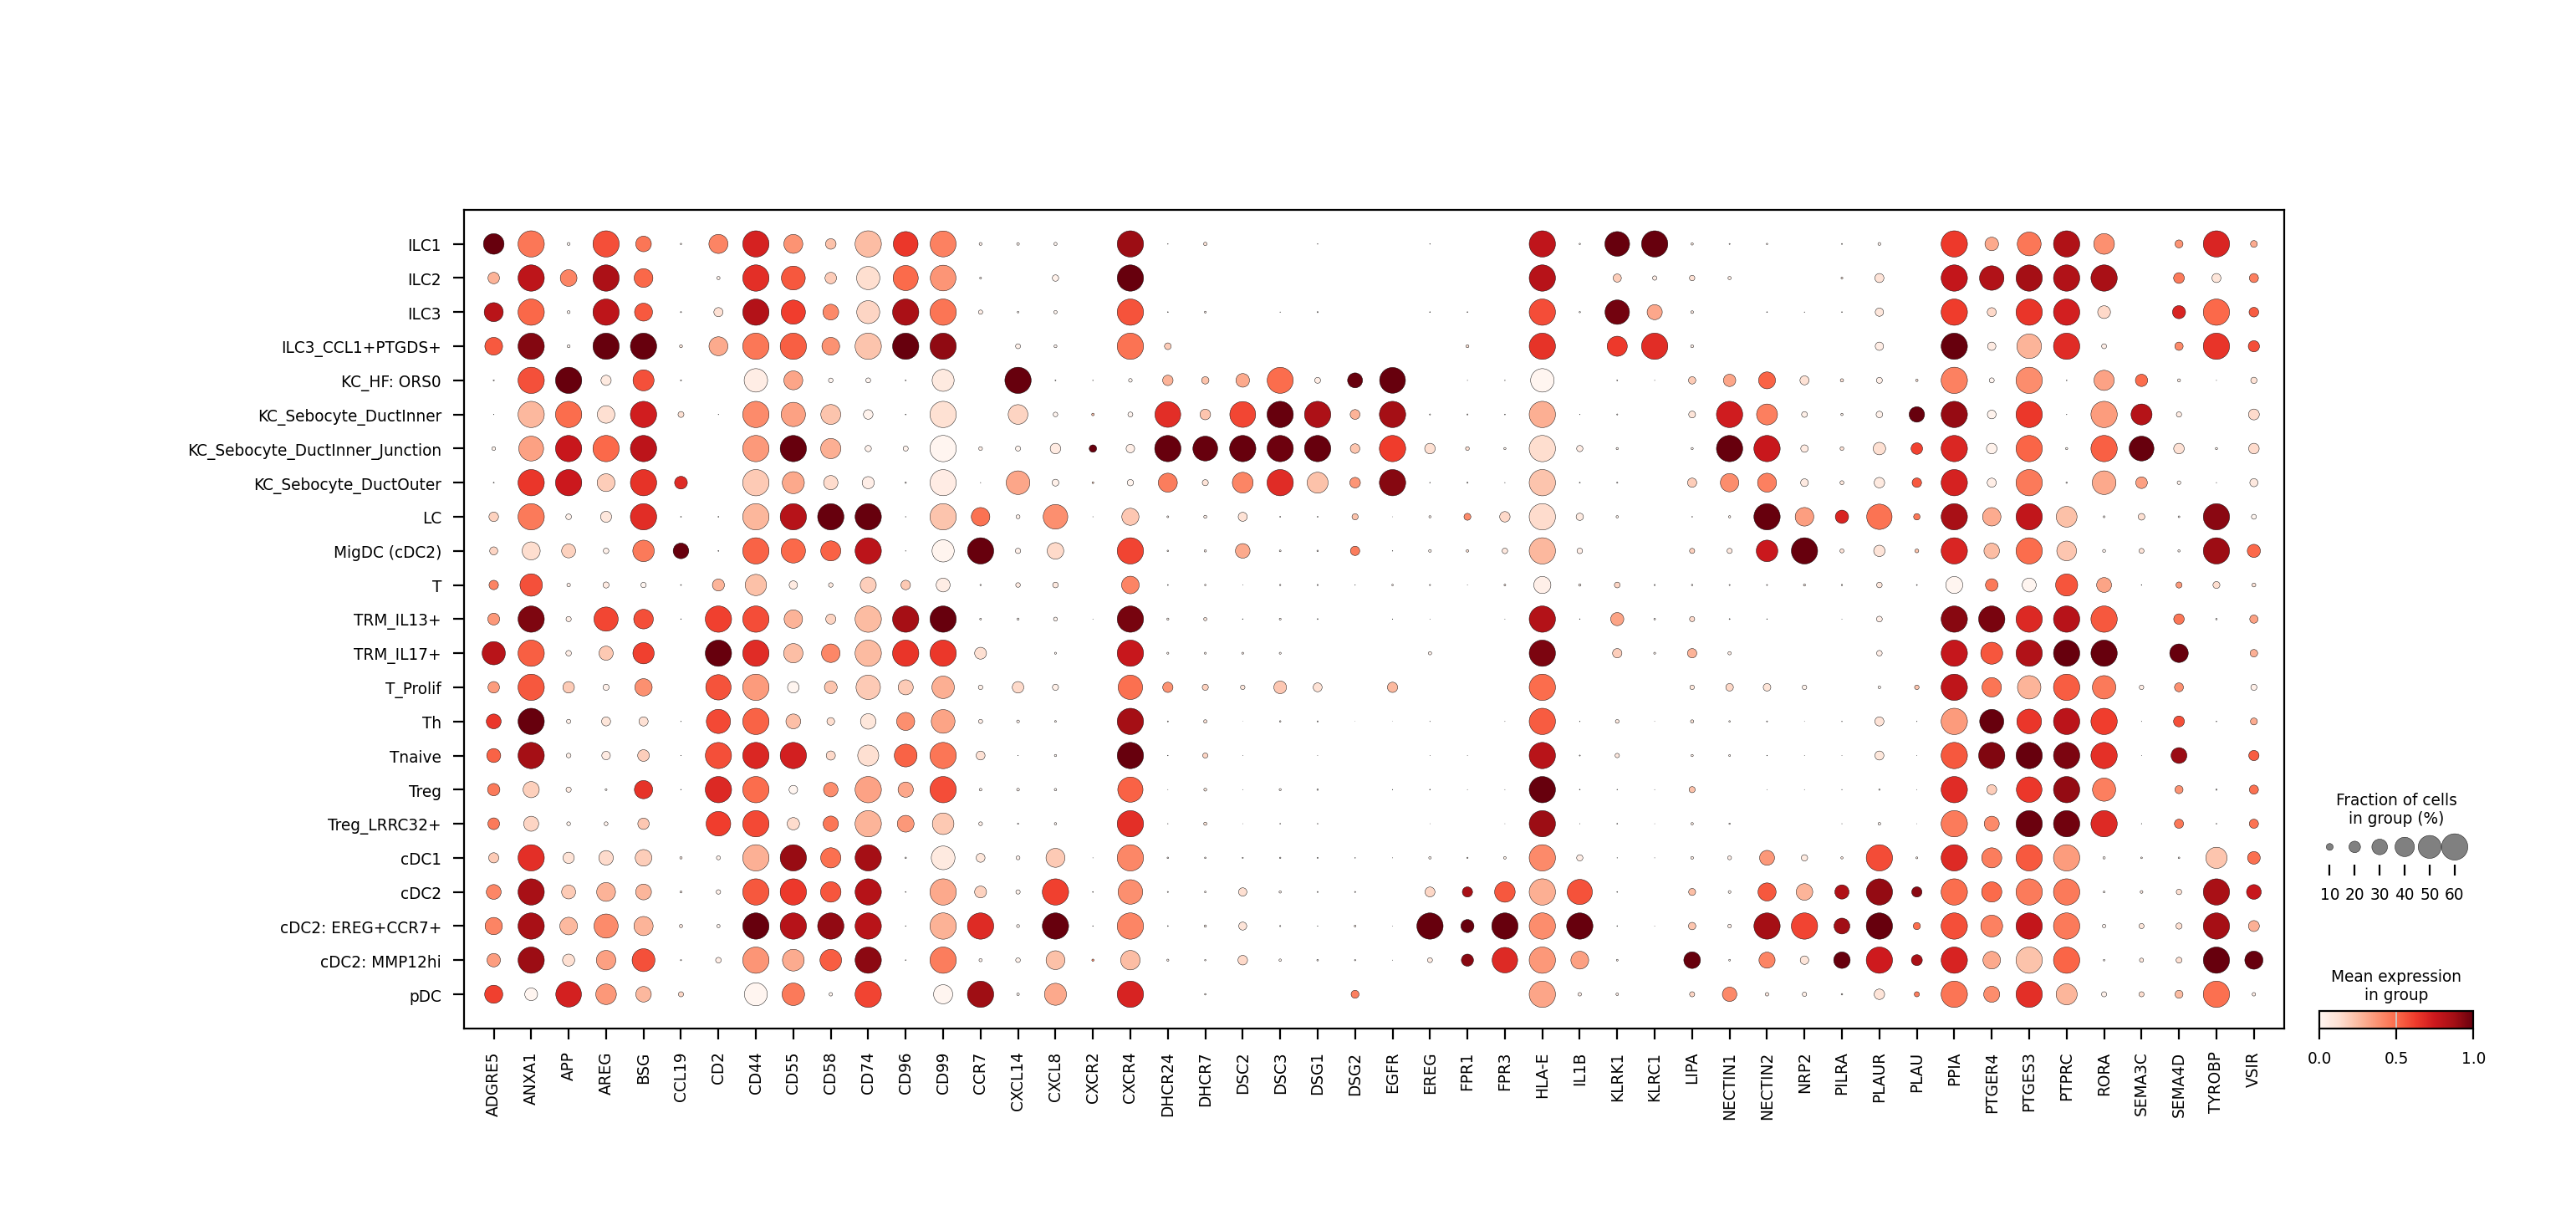

In [81]:
TEST = [
    'ADGRE5', 'ANXA1', 'APP', 'AREG', 'BSG', 'CCL19', 'CD2', 'CD44', 'CD55',
    'CD58', 'CD74', 'CD96', 'CD99', 'CCR7', 'CXCL14', 'CXCL8', 'CXCR2',
    'CXCR4', 'DHCR24', 'DHCR7', 'DSC2', 'DSC3', 'DSG1', 'DSG2', 'EGFR',
    'EREG', 'FPR1', 'FPR3', 'HLA-E', 'IL1B', 'KLRK1', 'KLRC1', 'LIPA',
    'NECTIN1', 'NECTIN2', 'NRP2', 'PILRA', 'PLAUR', 'PLAU', 'PPIA',
    'PTGER4', 'PTGES3', 'PTPRC', 'RORA', 'SEMA3C', 'SEMA4D', 'TYROBP',
    'VSIR'
]
sc.pl.dotplot(adata, 
                  TEST,
                  groupby="lvl5_annotation",
                  dendrogram=False, 
                    standard_scale="var",
             # swap_axes=True,
                  title="",
    
              dot_max=.6
             )

In [97]:
keep = ["LC", "pDC", "cDC1", "cDC2","cDC2: EREG+CCR7+", "TRM_IL17+", "KC_Sebocyte_DuctOuter","Tnaive","TRM_IL17+"]

In [98]:
[x for x in keep if x not in adata.obs["lvl5_annotation"].unique()]

[]

In [103]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["MigDC (cDC2)"],#cDC2: MMP12hi cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(10, 5),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  


error: bad escape \M at position 0

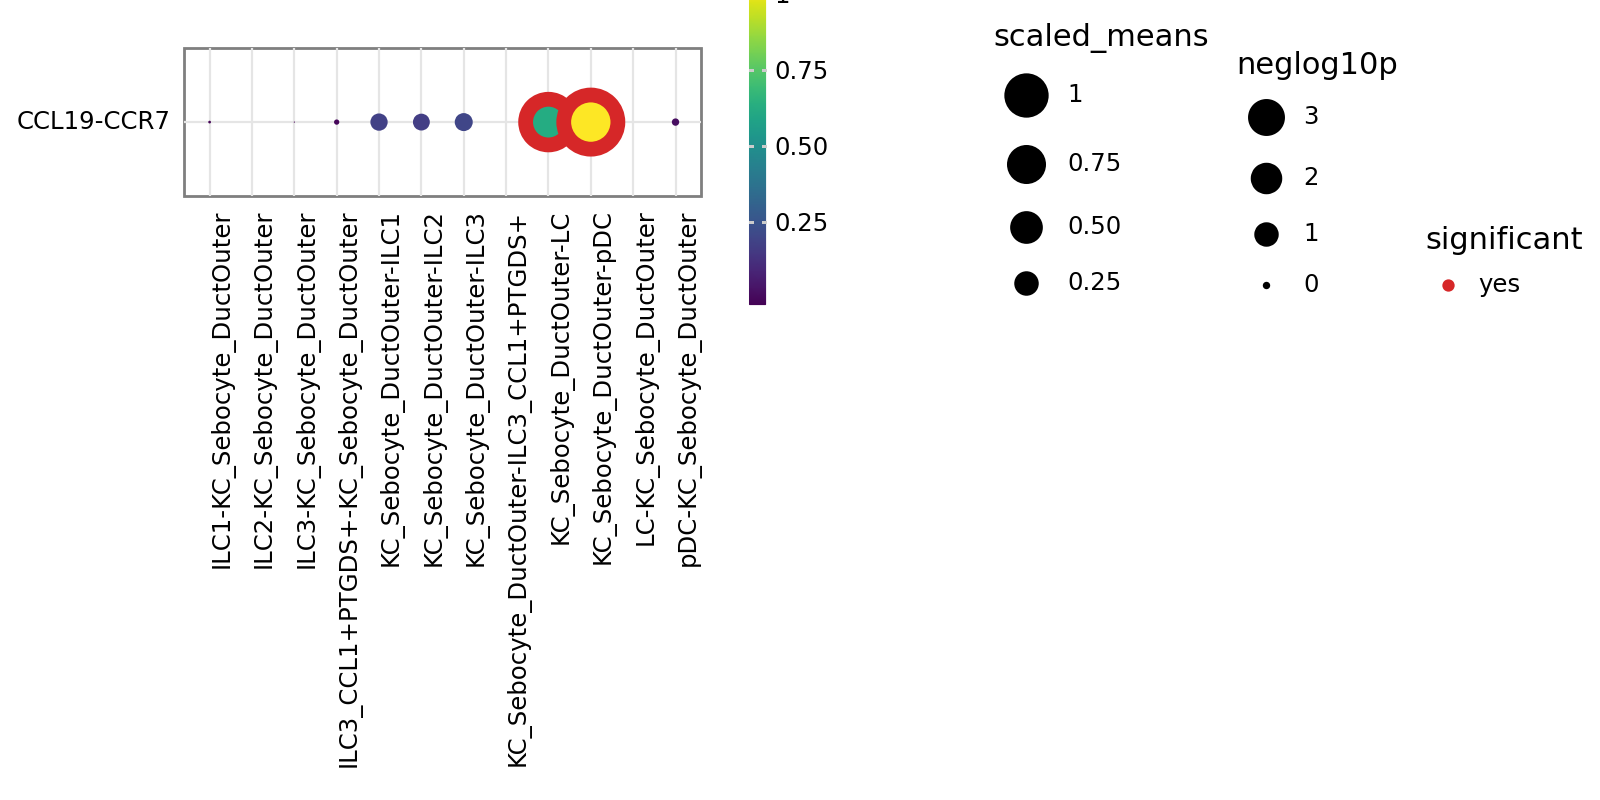

<Figure Size: (800 x 400)>

In [105]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["LC|pDC"],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(8, 4),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

In [111]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["MigDC (cDC2)"],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(12, 4),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

error: bad escape \M at position 0

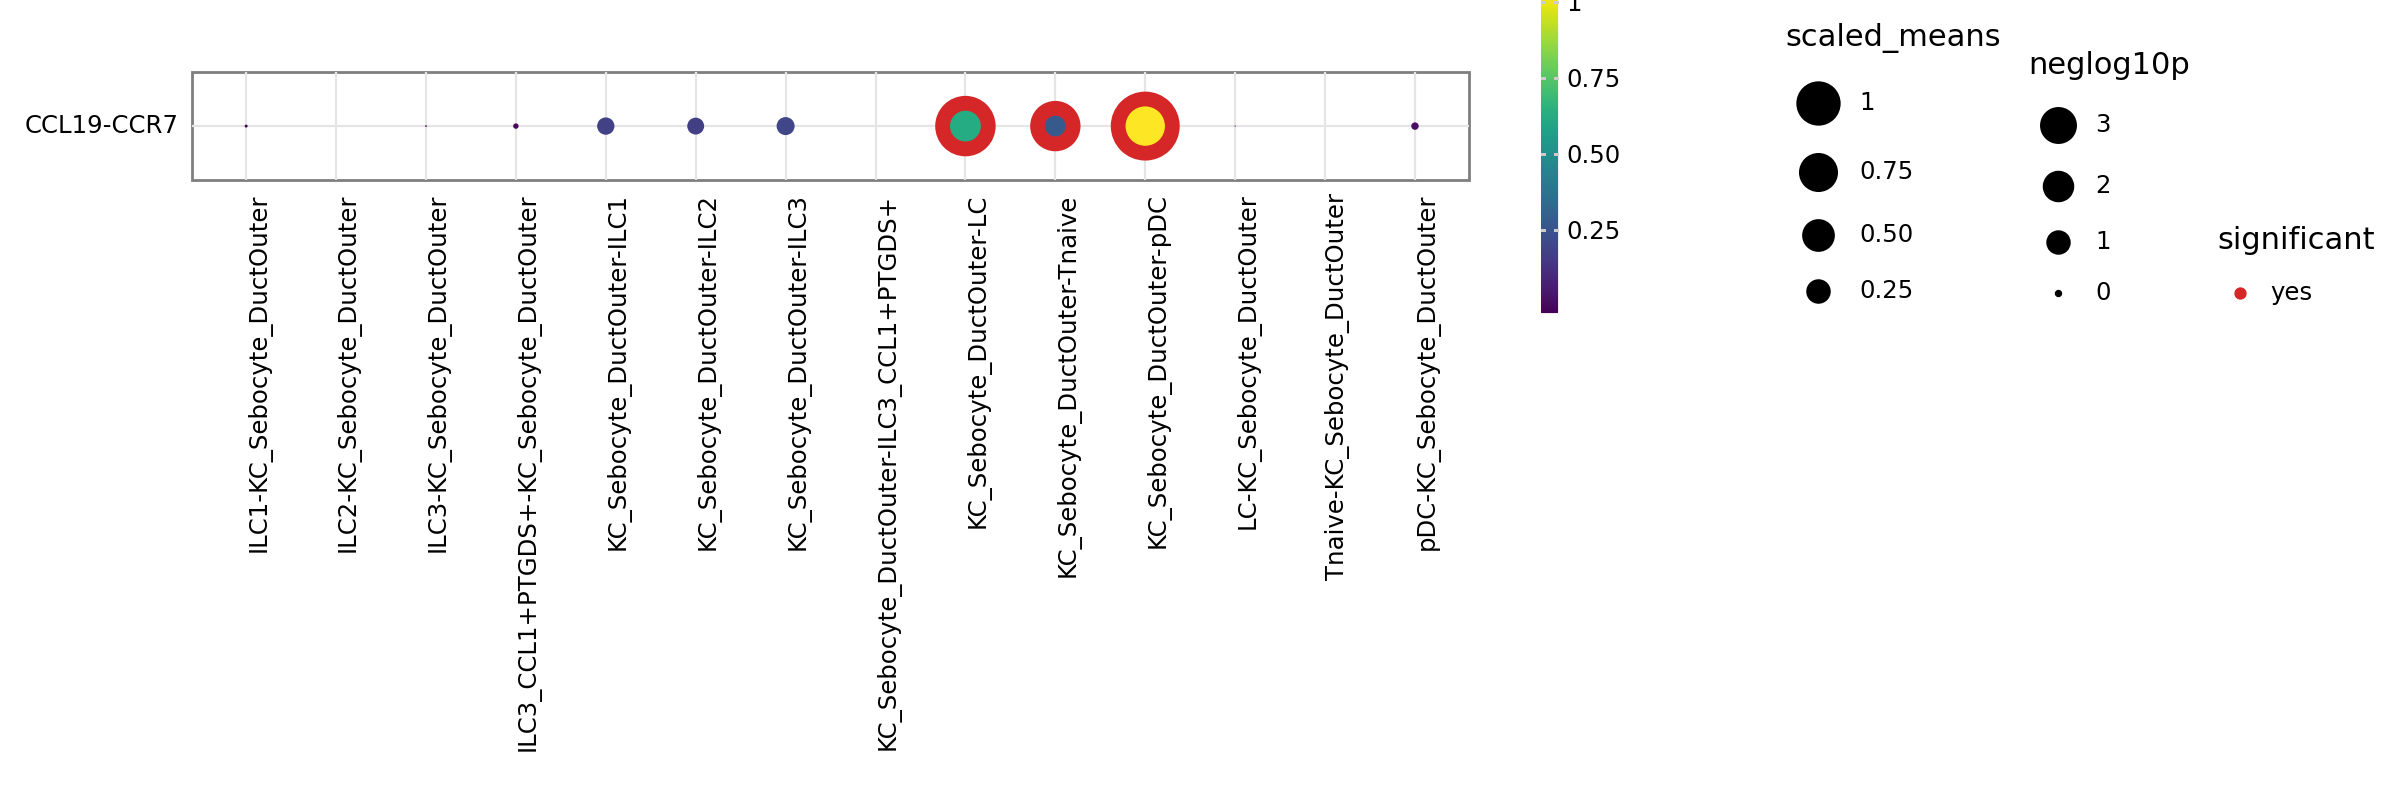

<Figure Size: (1200 x 400)>

In [106]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["LC|pDC|Tnaive"],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(12, 4),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

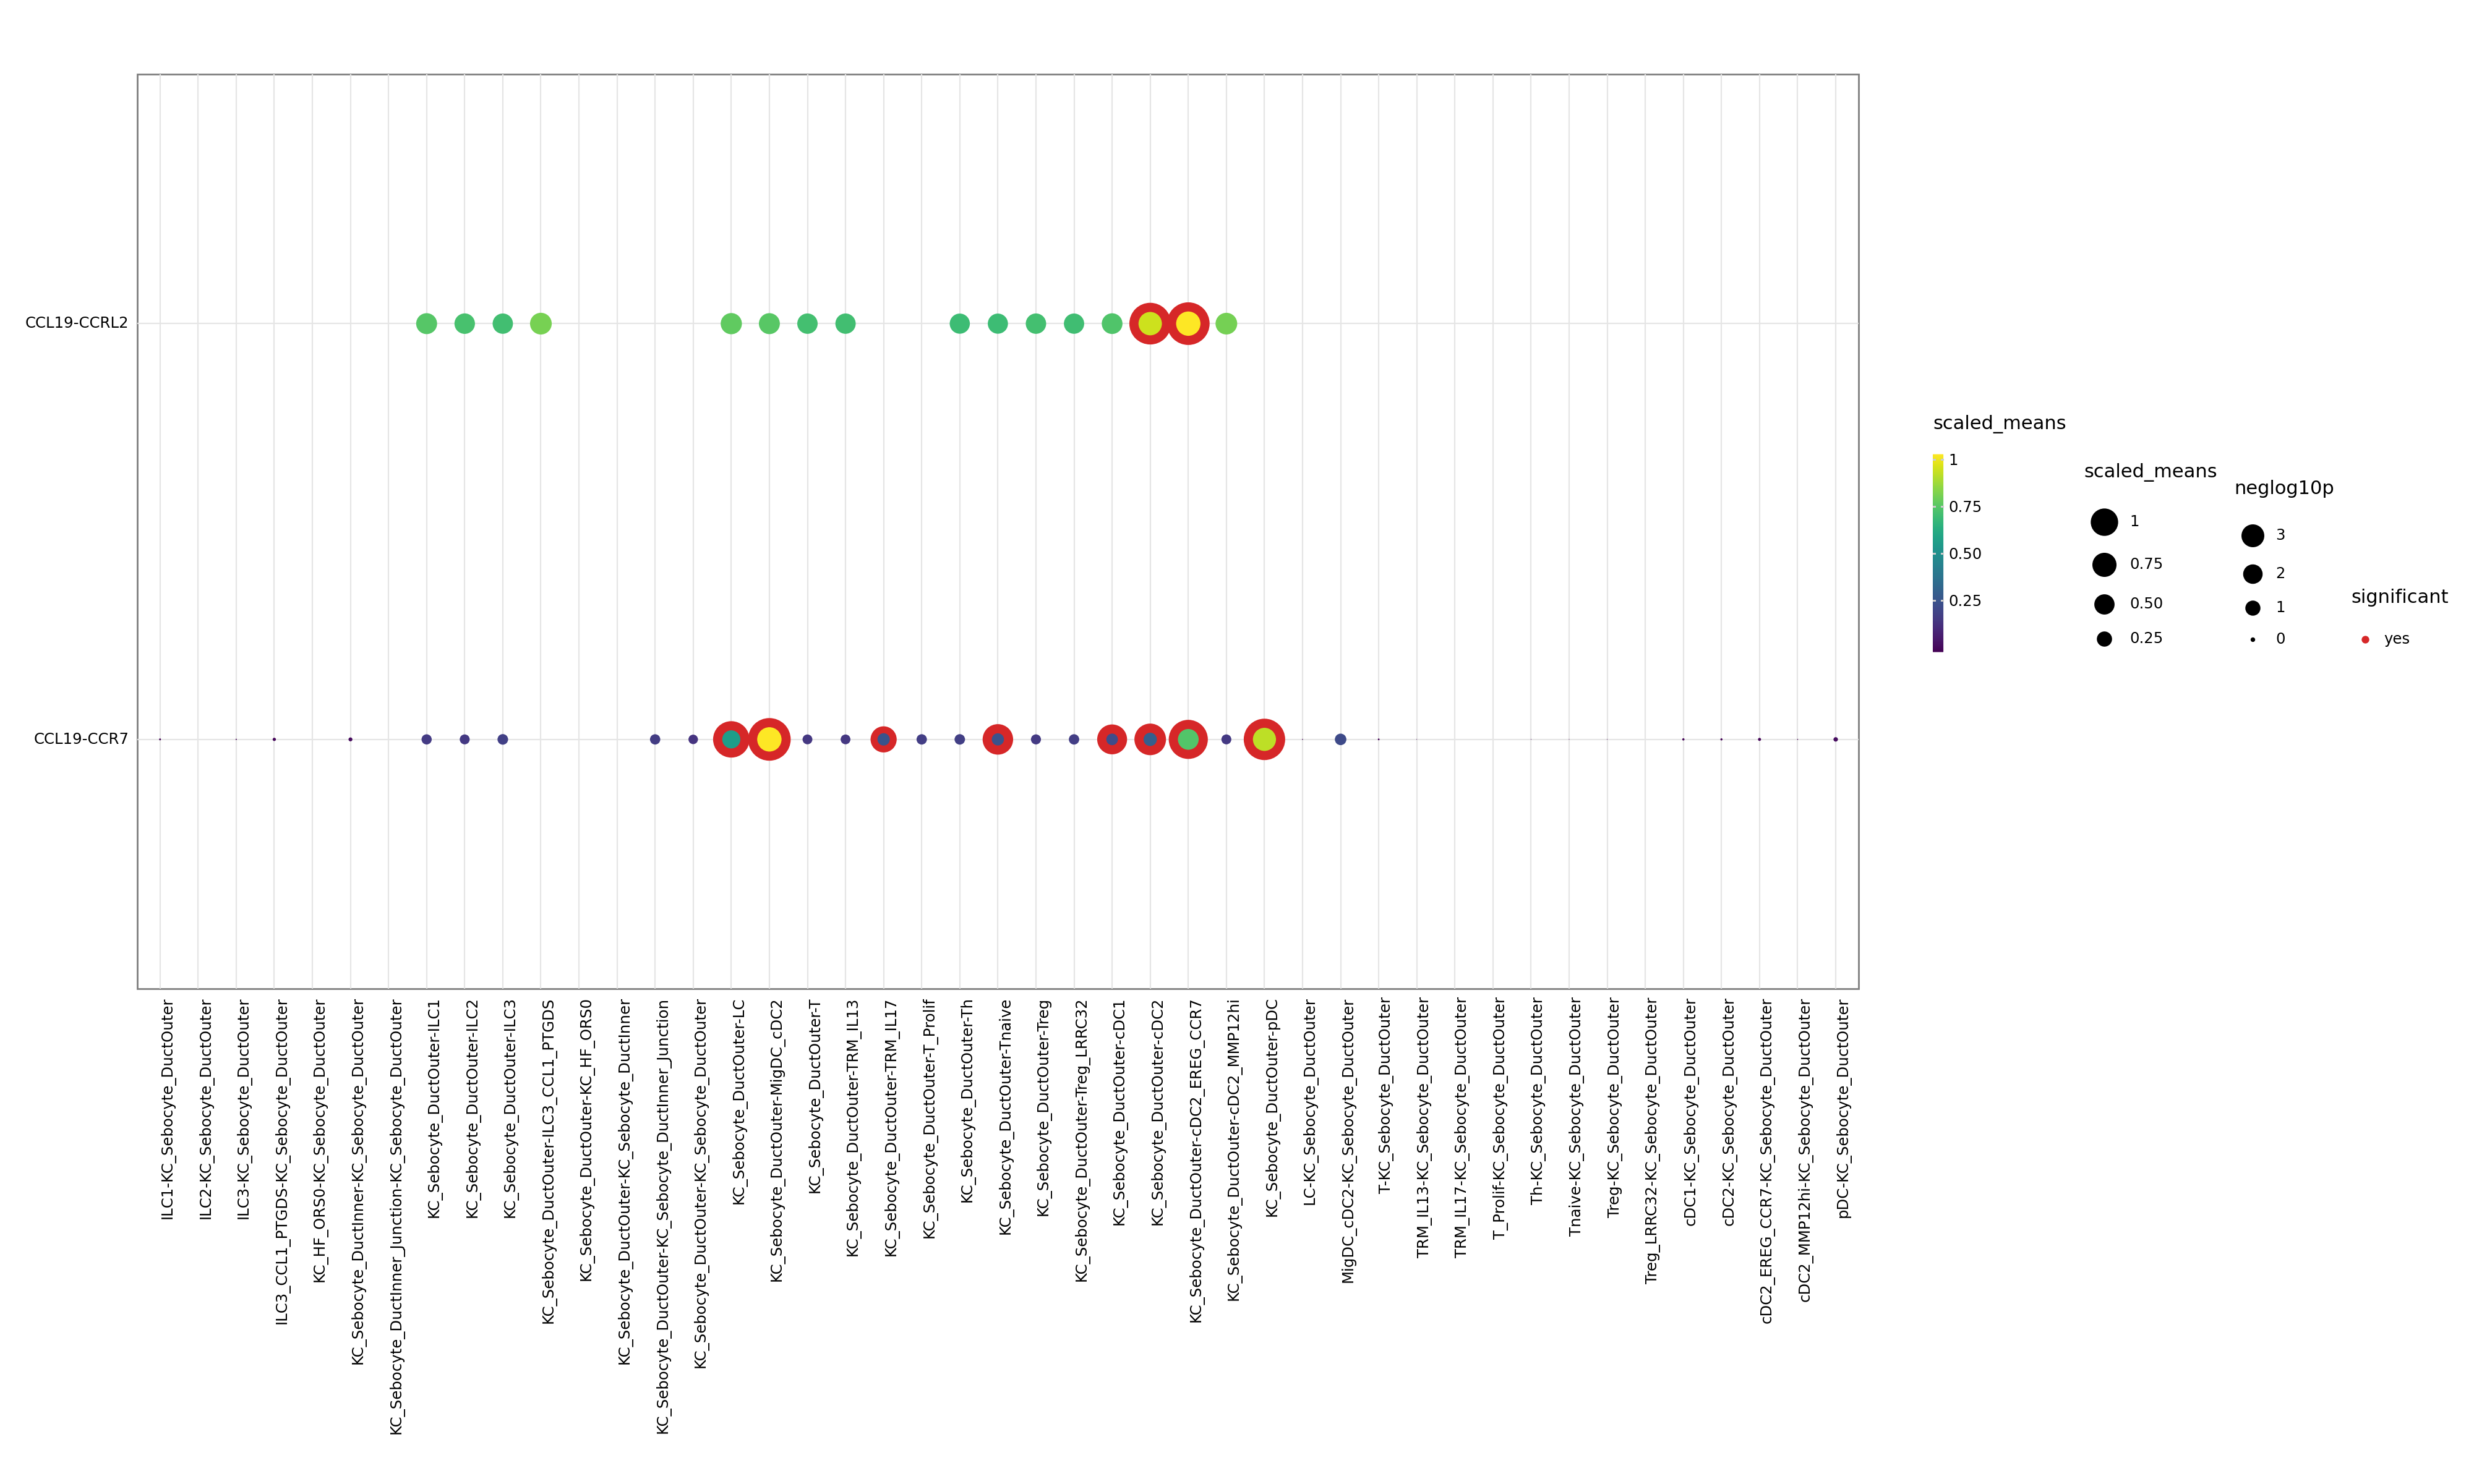

<Figure Size: (2000 x 1200)>

In [130]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["."],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(20, 12),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

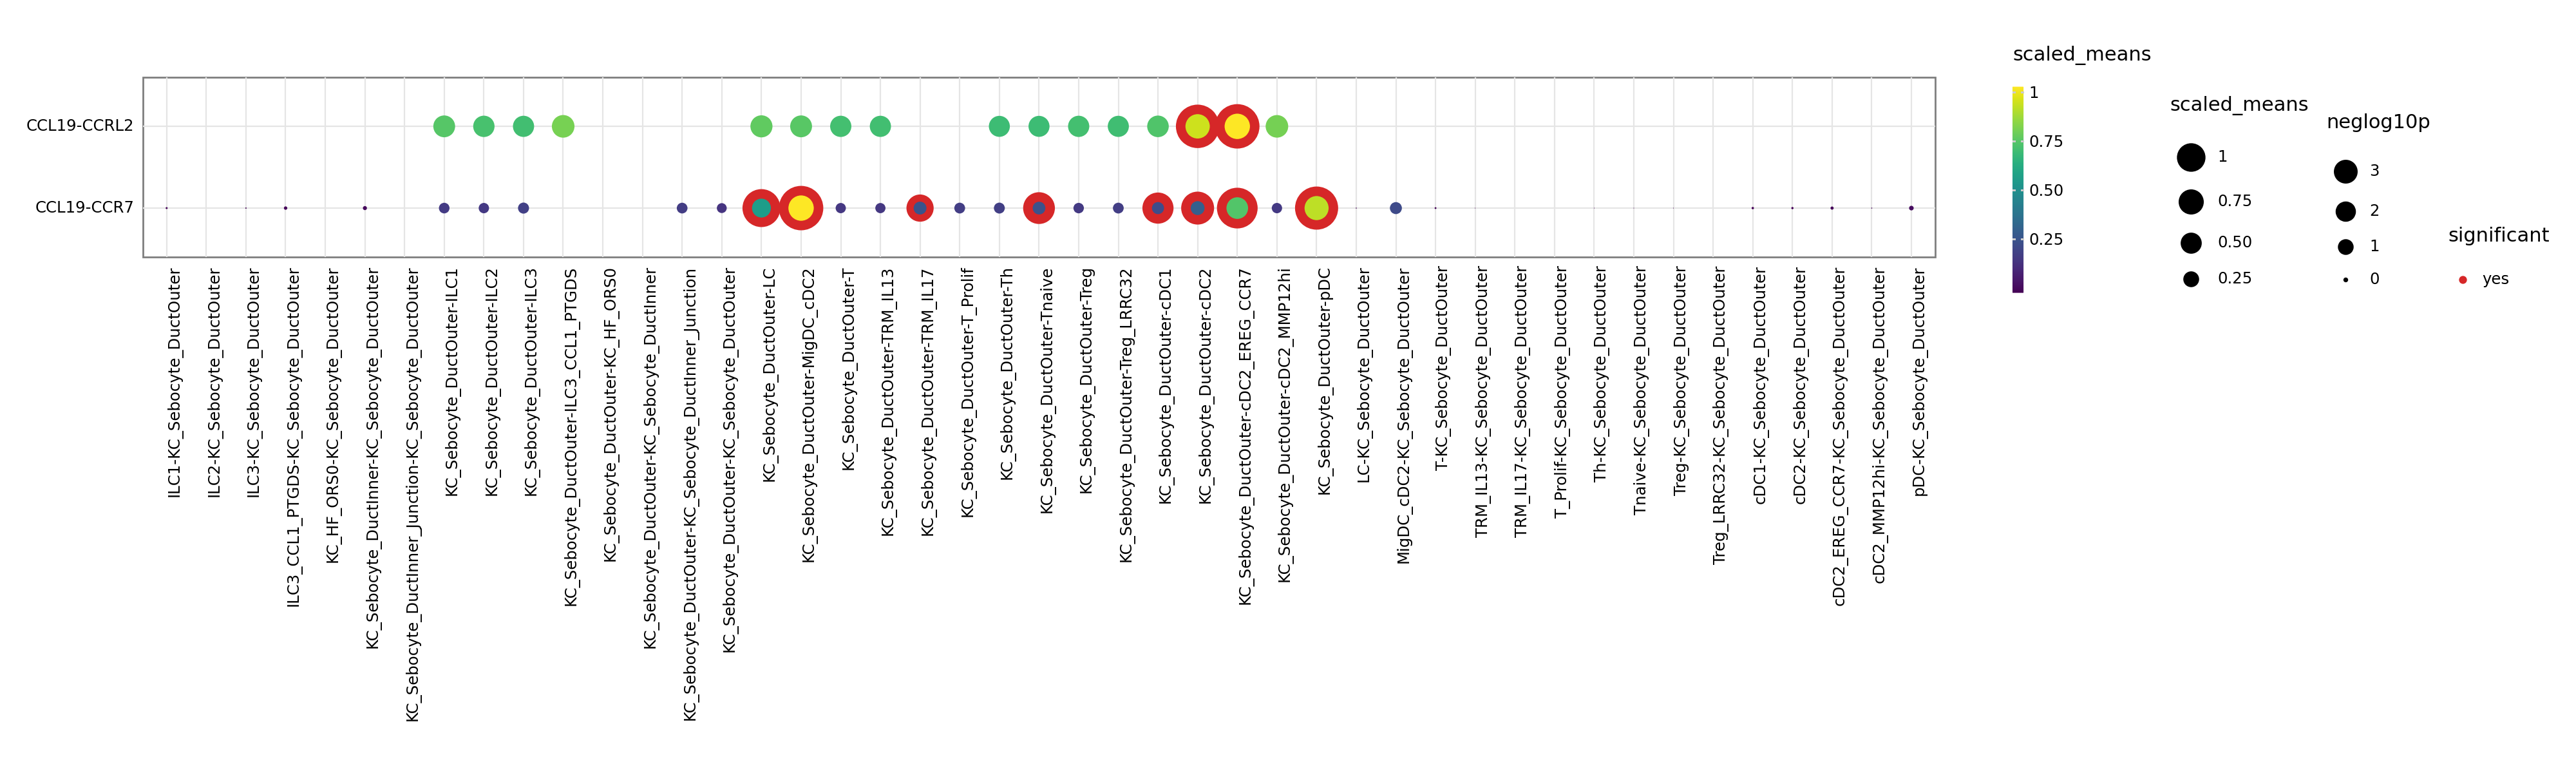

<Figure Size: (2000 x 600)>

In [135]:
sc.settings.set_figure_params(dpi=300, facecolor="white", frameon=False, figsize=(20,20))
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["."],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(20, 6),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

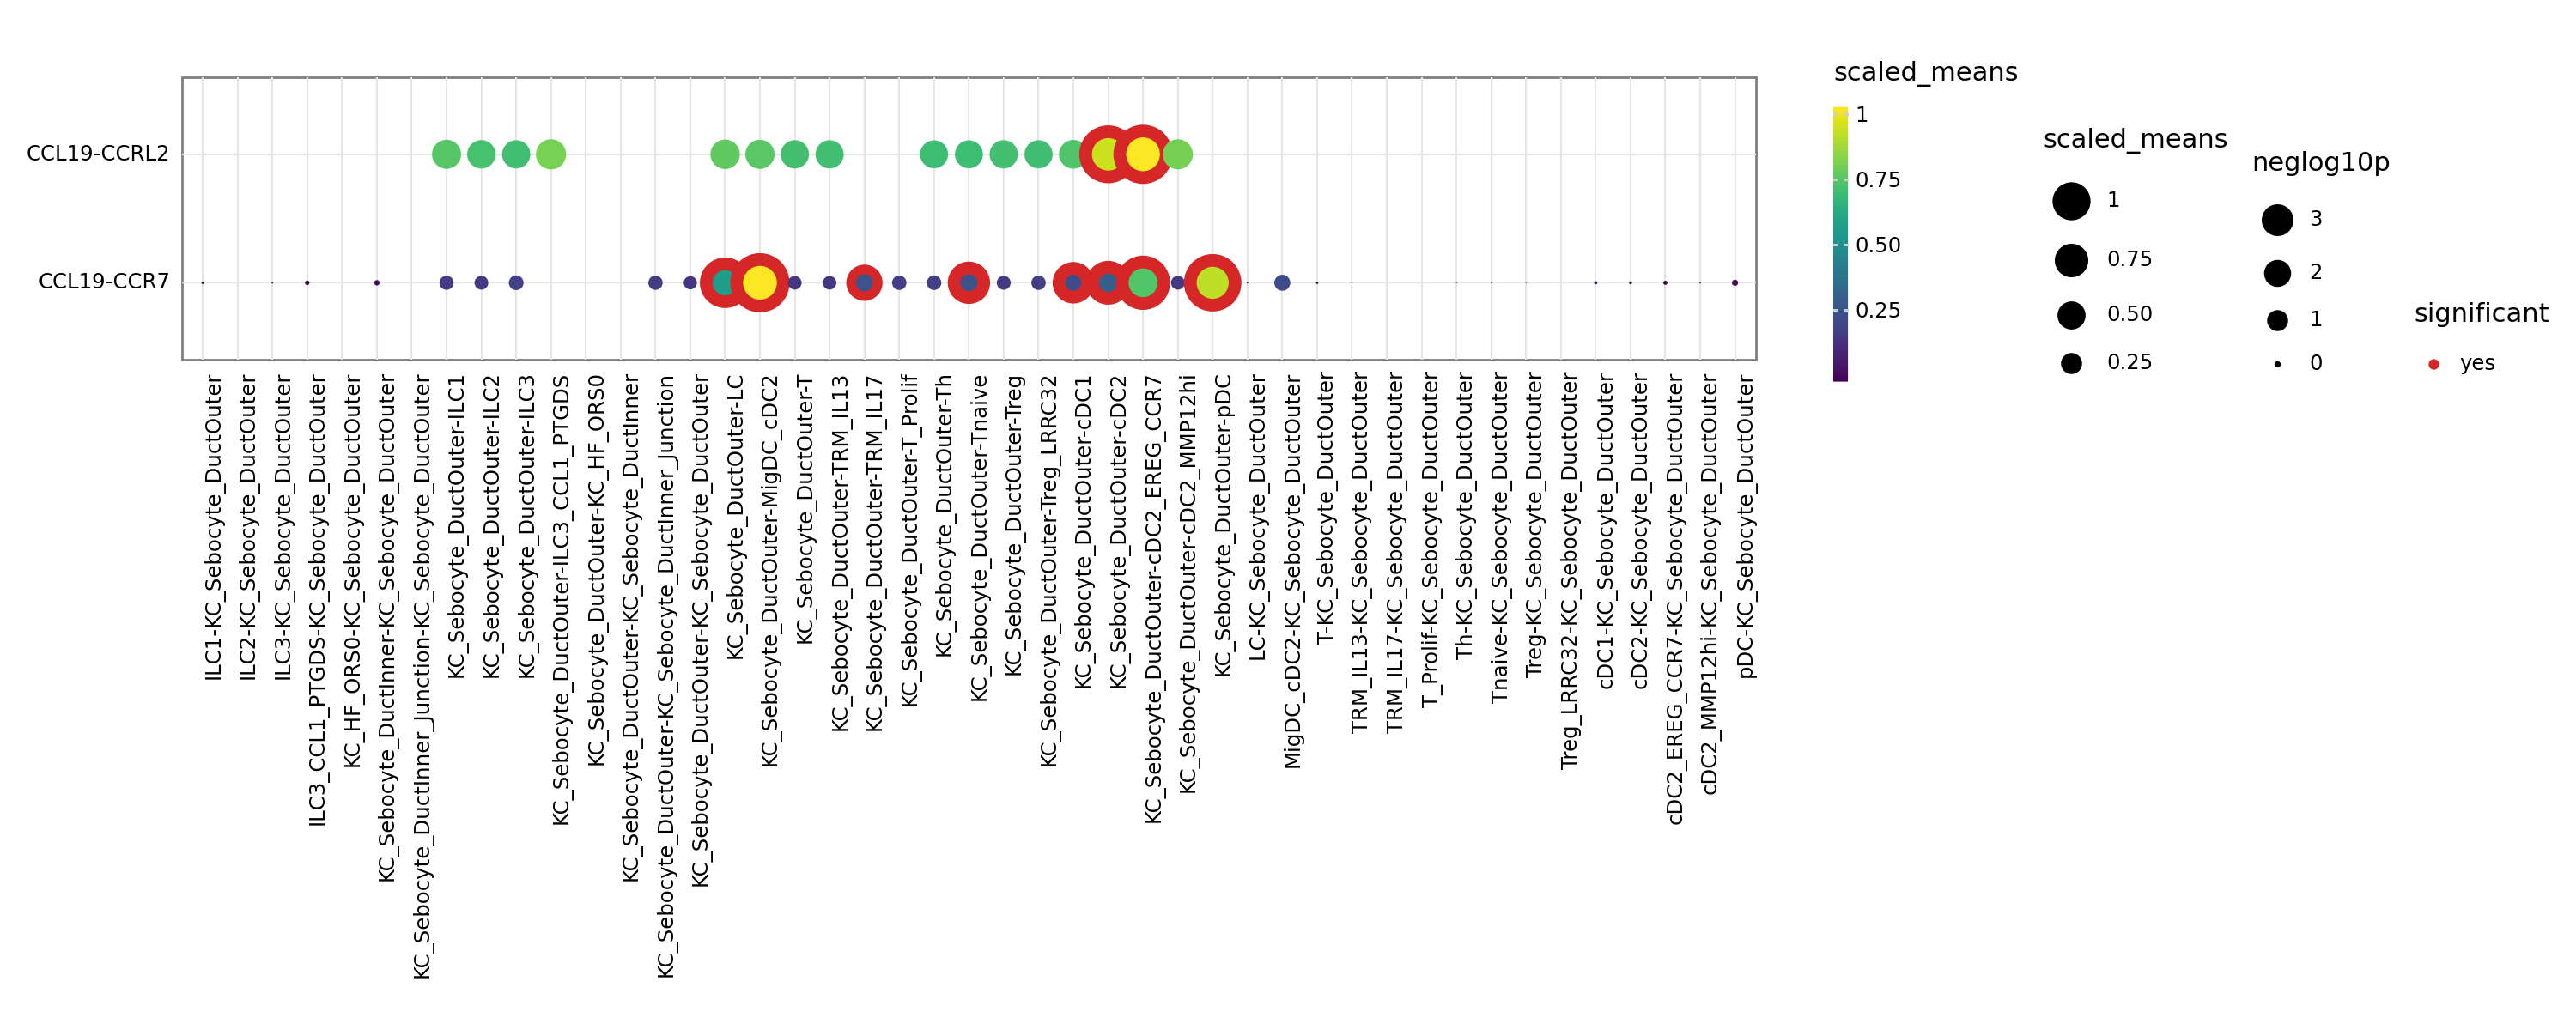

<Figure Size: (1500 x 600)>

In [136]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["."],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(15, 6),
        genes = [  "CCL19", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

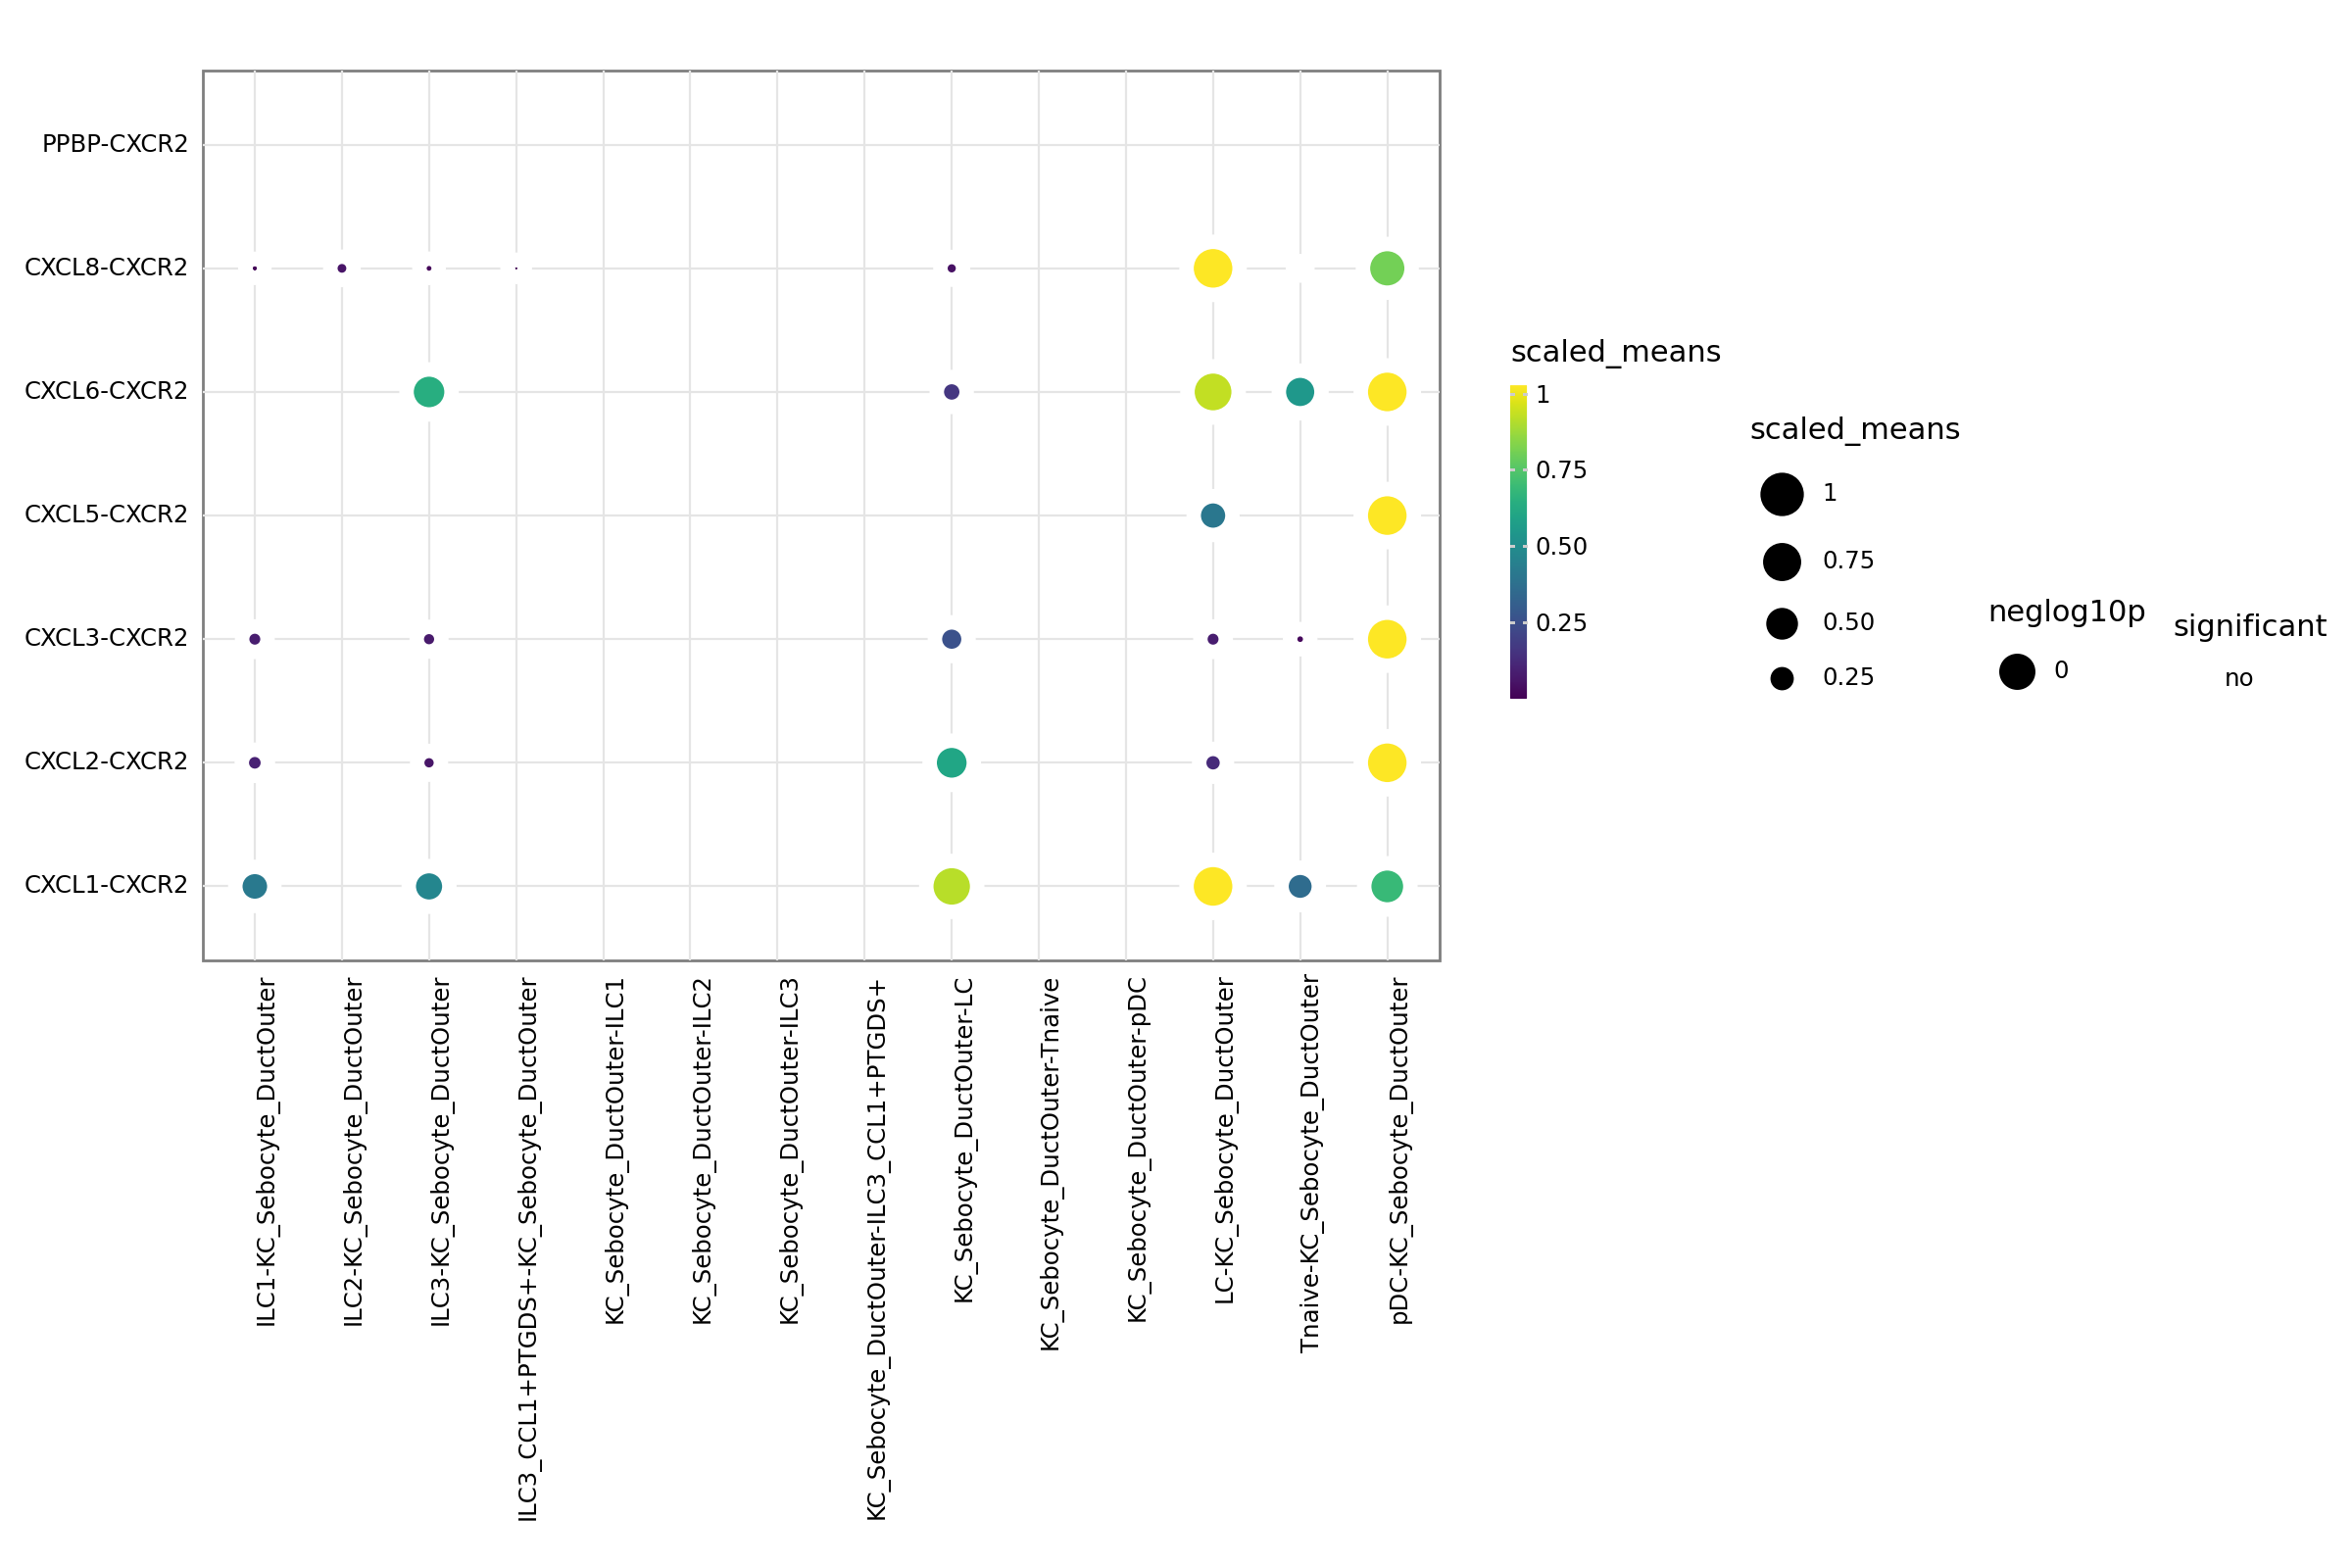

<Figure Size: (1200 x 800)>

In [108]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ["LC|pDC|Tnaive"],#cDC2: EREG+CCR7+| |MigDC (cDC2)"cDC1", "cDC2","", "TRM_IL17+", "KC_Sebocyte_DuctOuter","","TRM_IL17+"],
    
    cell_type2=  ['KC_Sebocyte_DuctOuter'],
    means=means,
    pvals=pvals,

   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(12, 8),
        genes = [  "CXCR2", ],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)
  

In [63]:
IMMUNE = ['Treg',
                          'cDC2: MMP12hi',
                          'cDC2',
                          'Th',
                          'MigDC (cDC2)',
                          'Tnaive',
                          'cDC1','TRM_IL13+',
                          'Treg_LRRC32+',
                          'ILC3',
                          'cDC2: EREG+CCR7+',
                          'LC', 'ILC2', 'ILC1', 'TRM_IL17+','pDC','ILC3_CCL1+PTGDS+']  # List of cells 1, will be paired to cells 2 (list or 'All').
DUCT = ['KC_Sebocyte_DuctOuter', 'KC_Sebocyte_DuctInner', 'KC_Sebocyte_DuctInner_Junction', 'KC_HF: ORS0']


In [74]:
IMMUNE= ['Treg|cDC2: MMP12hi|cDC2|Th|MigDC (cDC2)|Tnaive|cDC1|TRM_IL13+|Treg_LRRC32+ILC3|cDC2: EREG+CCR7+LC|ILC2|ILC1|TRM_IL17+|pDC|ILC3_CCL1+PTGDS+']
DUCT = ['KC_Sebocyte_DuctOuter|KC_Sebocyte_DuctInner|KC_Sebocyte_DuctInner_Junction|KC_HF: ORS0']
  

In [89]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



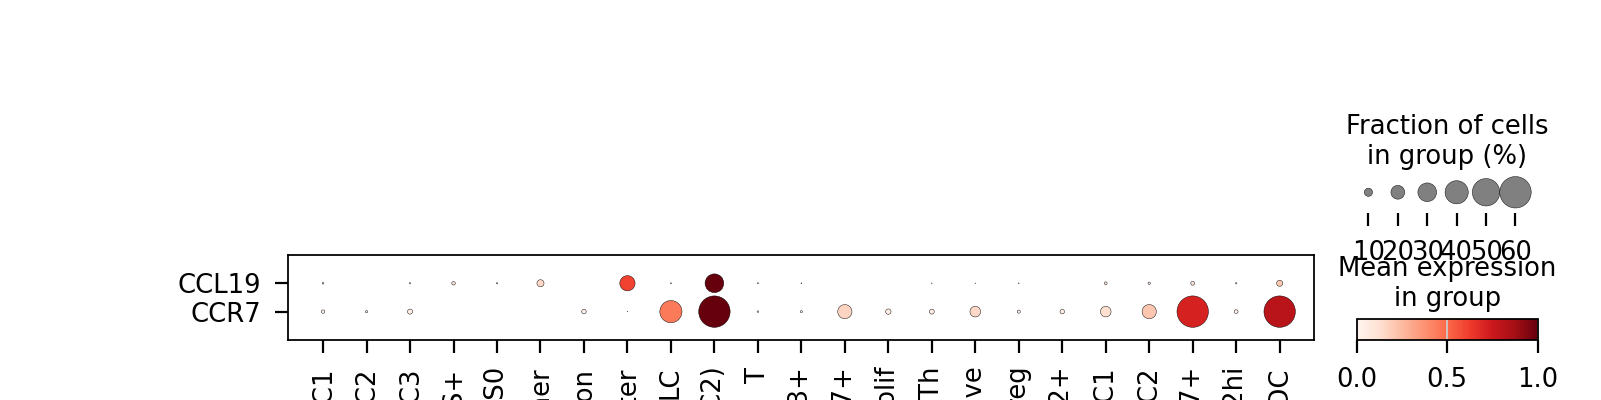

In [92]:
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(20,20))

sc.pl.dotplot(adata, 
                  ["CCL19", "CCR7"],
                  groupby="lvl5_annotation",
                  dendrogram=False, 
                    standard_scale="var",
              swap_axes=True,
                  title="",
    
              dot_max=.6
             )

In [93]:
adata.obs.lvl5_annotation.value_counts()

lvl5_annotation
Th                                2140
LC                                1118
Treg_LRRC32+                      1092
cDC2: EREG+CCR7+                   967
cDC2                               815
Tnaive                             762
cDC2: MMP12hi                      734
T                                  729
Treg                               721
TRM_IL13+                          719
cDC1                               668
KC_HF: ORS0                        565
KC_Sebocyte_DuctOuter              424
ILC3                               341
KC_Sebocyte_DuctInner              341
MigDC (cDC2)                       306
ILC1                               253
pDC                                 74
ILC2                                55
TRM_IL17+                           53
KC_Sebocyte_DuctInner_Junction      45
T_Prolif                            35
ILC3_CCL1+PTGDS+                    31
Name: count, dtype: int64

['LC',
 'pDC',
 'cDC1',
 'cDC2',
 'cDC2: EREG+CCR7+',
 'TRM_IL17+',
 'KC_Sebocyte_DuctOuter',
 'Tnaive',
 'TRM_IL17+']

In [ ]:
STOP

In [82]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna'
adata=sc.read_h5ad(PATH)


In [83]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)



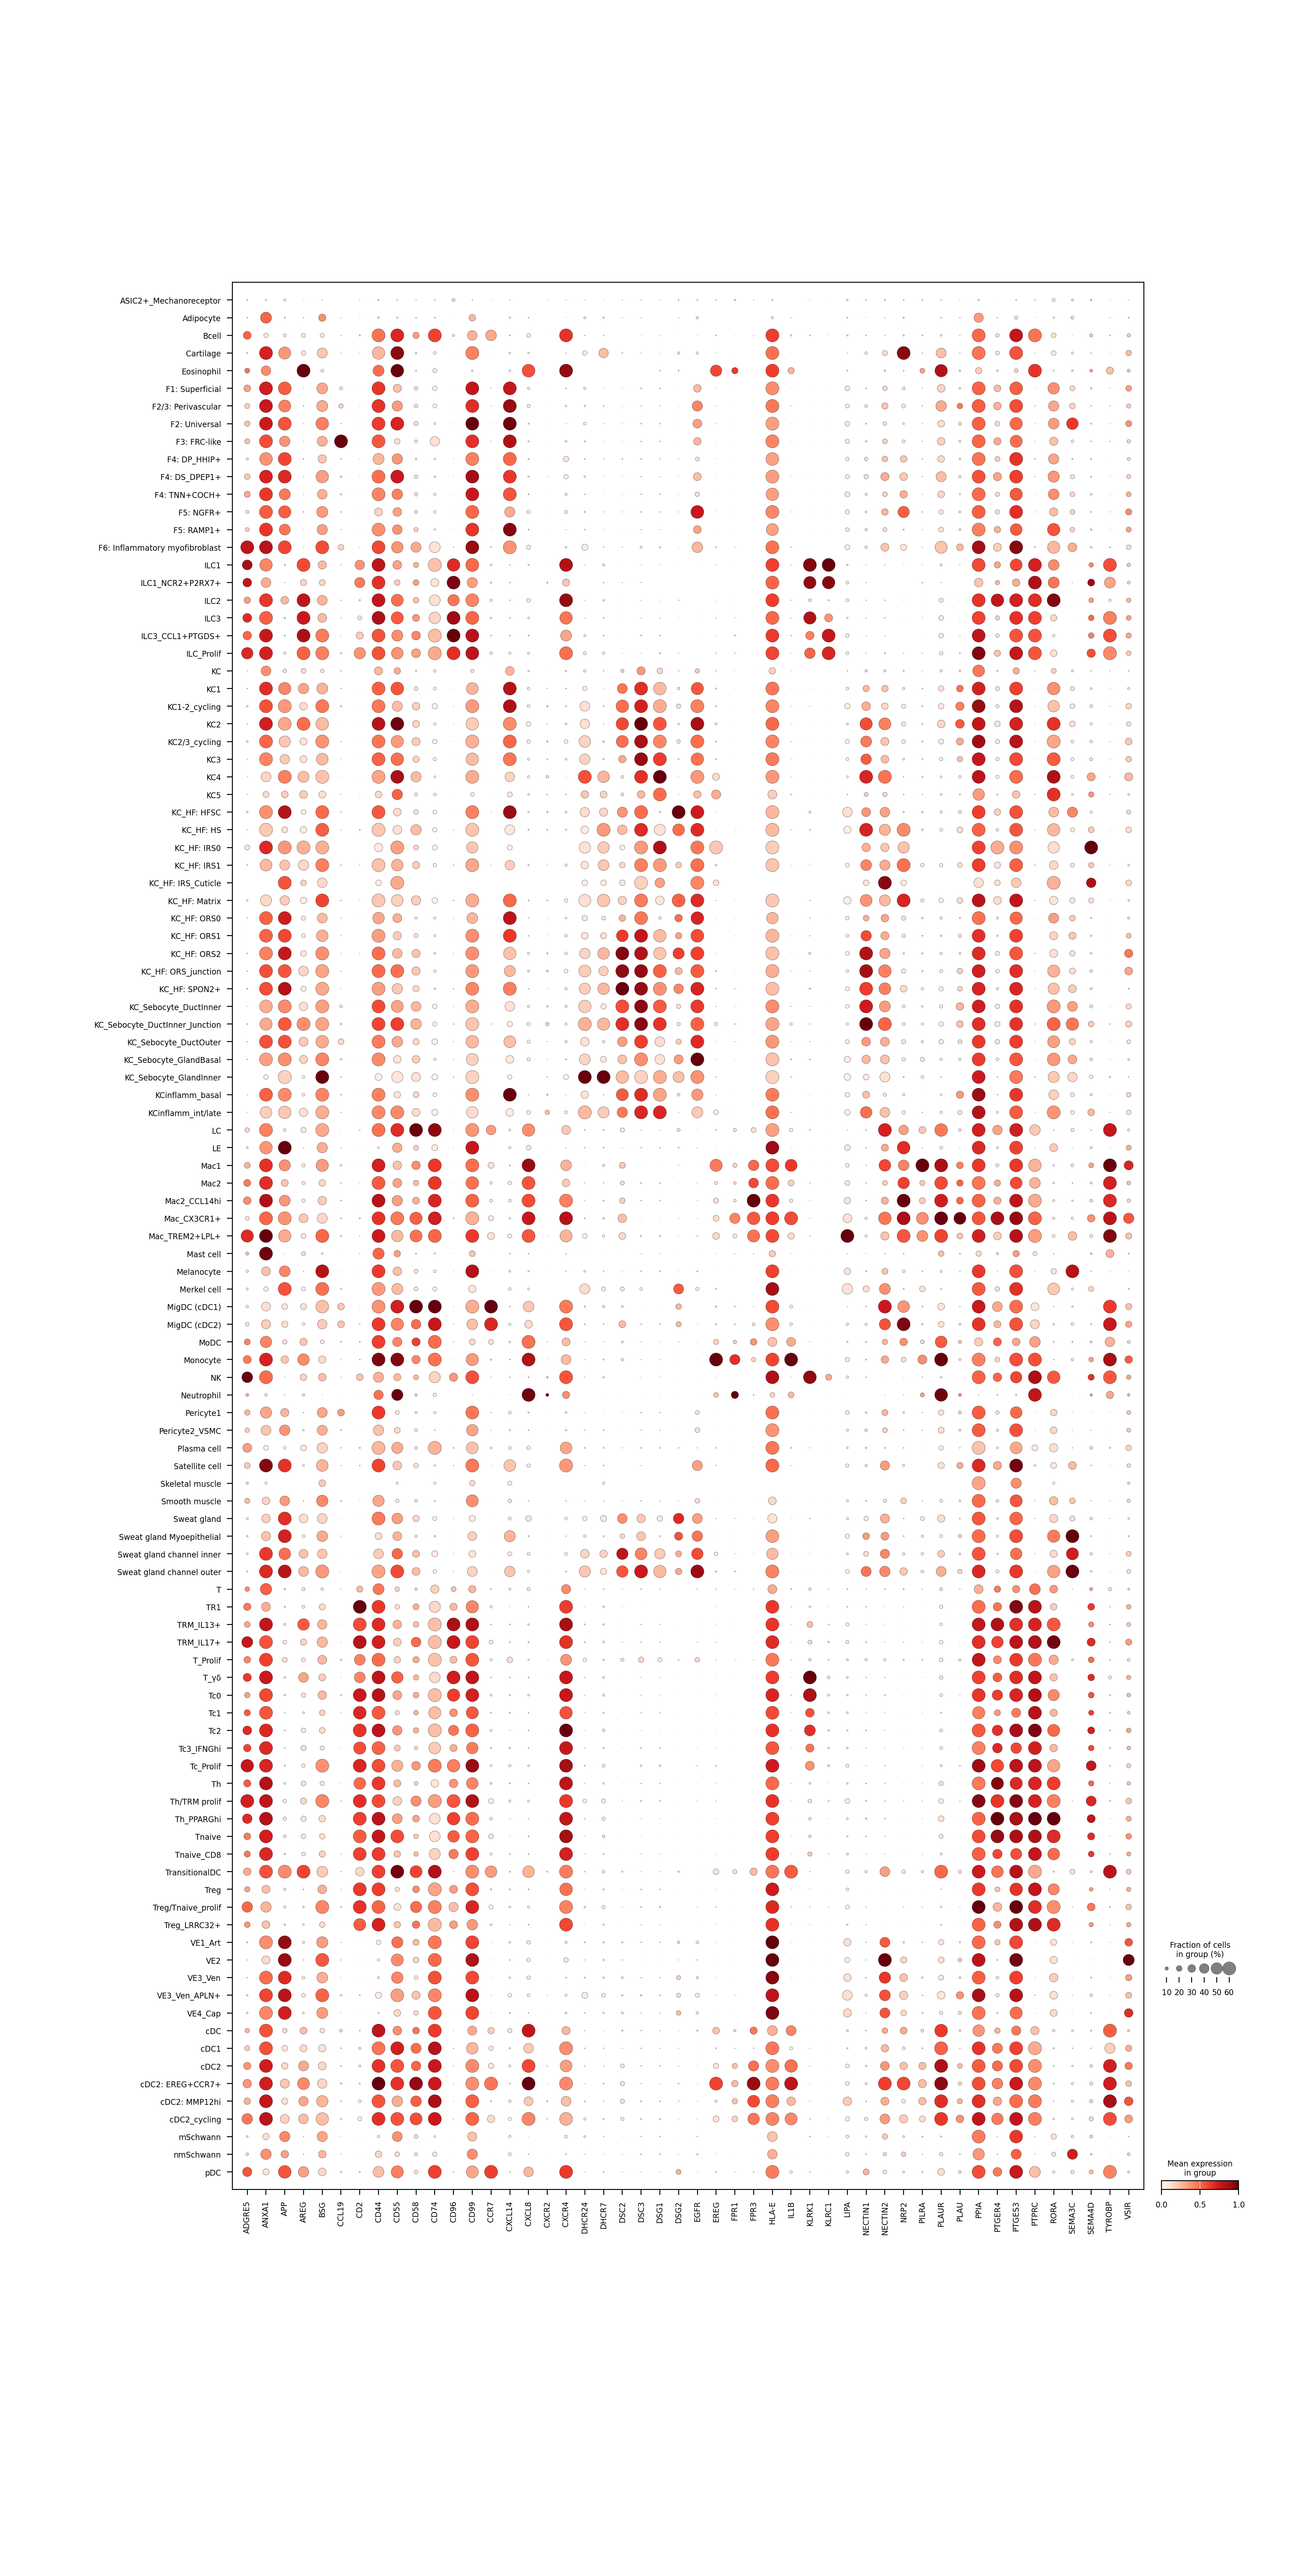

In [84]:
TEST = [
    'ADGRE5', 'ANXA1', 'APP', 'AREG', 'BSG', 'CCL19', 'CD2', 'CD44', 'CD55',
    'CD58', 'CD74', 'CD96', 'CD99', 'CCR7', 'CXCL14', 'CXCL8', 'CXCR2',
    'CXCR4', 'DHCR24', 'DHCR7', 'DSC2', 'DSC3', 'DSG1', 'DSG2', 'EGFR',
    'EREG', 'FPR1', 'FPR3', 'HLA-E', 'IL1B', 'KLRK1', 'KLRC1', 'LIPA',
    'NECTIN1', 'NECTIN2', 'NRP2', 'PILRA', 'PLAUR', 'PLAU', 'PPIA',
    'PTGER4', 'PTGES3', 'PTPRC', 'RORA', 'SEMA3C', 'SEMA4D', 'TYROBP',
    'VSIR'
]
sc.pl.dotplot(adata, 
                  TEST,
                  groupby="lvl5_annotation",
                  dendrogram=False, 
                    standard_scale="var",
             # swap_axes=True,
                  title="",
    
              dot_max=.6
             )

In [75]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= IMMUNE,
    cell_type2=  DUCT,
    means=means,
    pvals=pvals,
   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
        figsize=(30, 30),
        #genes = [  "CCL17", "CCL22", "CCL5", "CCL19"],

   # size=0.00001,
   #  scale_lw=0.00001,
    interaction=
    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)

TypeError: plot_cpdb() got an unexpected keyword argument 'interaction'

In [59]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1= ['Treg|cDC2: MMP12hi|cDC2|Th|MigDC (cDC2)|Tnaive|cDC1|TRM_IL13+|Treg_LRRC32+ILC3|cDC2: EREG+CCR7+LC|ILC2|T|ILC1|T_Prolif|TRM_IL17+|pDC|ILC3_CCL1+PTGDS+'],  # List of cells 1, will be paired to cells 2 (list or 'All').
    
    cell_type2=  ['KC_Sebocyte_DuctOuter|KC_Sebocyte_DuctInner|KC_Sebocyte_DuctInner_Junction|KC_HF: ORS0'],
    means=means,
    pvals=pvals,
   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
   # separator="|",
        figsize=(20, 20),
        #genes = [  "CCL17", "CCL22", "CCL5", "CCL19"],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)

TypeError: plot_cpdb() got an unexpected keyword argument 'separator'

In [ ]:
## WAIT FOR PLOT ABOVE

In [39]:

from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Treg|cDC2: MMP12hi|cDC2|Th|MigDC (cDC2)|Tnaive|cDC1|TRM_IL13+|Treg_LRRC32+ILC3|cDC2: EREG+CCR7+LC|ILC2|T|ILC1|T_Prolif|TRM_IL17+|pDC|ILC3_CCL1+PTGDS+'],  # List of cells 1, will be paired to cells 2 (list or 'All').
    #query_cell_types_2 =  adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
     query_cell_types_2 =  ['KC_Sebocyte_DuctOuter|KC_Sebocyte_DuctInner|KC_Sebocyte_DuctInner_Junction|KC_HF: ORS0'],
     #    query_cell_types_2 =  ['KC2/3_cycling', 'KC_Sebocyte_duct_inner', 'cDC2',
     #                       'LC', 'cDC2: MMP12hi', 'KC_Sebocyte_duct_basal/outer',
     #                       'KCinflamm_basal', 'cDC1',
     #                       'KC_HF: ORS 1/2', 'MigDC (cDC2)', 'MigDC (cDC1)'],
    #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 1,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)
#search_results=search_results[search_results["significant_mean"]>.2]
search_results.head(50)


,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean


In [42]:

from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['MigDC (cDC2)', "Tnaive"],  # List of cells 1, will be paired to cells 2 (list or 'All').
    #query_cell_types_2 =  adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
     query_cell_types_2 =  ['KC_Sebocyte_DuctOuter'],
     #    query_cell_types_2 =  ['KC2/3_cycling', 'KC_Sebocyte_duct_inner', 'cDC2',
     #                       'LC', 'cDC2: MMP12hi', 'KC_Sebocyte_duct_basal/outer',
     #                       'KCinflamm_basal', 'cDC1',
     #                       'KC_HF: ORS 1/2', 'MigDC (cDC2)', 'MigDC (cDC1)'],
    #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 1,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)
search_results=search_results[search_results["significant_mean"]>.5]
search_results.head(50)


,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean
11,APP_CD74,simple:P05067,simple:P04233,APP,CD74,Ligand-Receptor,Signaling by Amyloid-beta precursor protein,KC_Sebocyte_DuctOuter|MigDC (cDC2),2.685
12,APP_SORL1,simple:P05067,simple:Q92673,APP,SORL1,Ligand-Receptor,Signaling by Amyloid-beta precursor protein,KC_Sebocyte_DuctOuter|MigDC (cDC2),0.501
16,CCL19_CCR7,simple:Q99731,simple:P32248,CCL19,CCR7,Ligand-Receptor,Signaling by Chemokines,KC_Sebocyte_DuctOuter|MigDC (cDC2),1.175
18,CXCL14_CXCR4,simple:O95715,simple:P61073,CXCL14,CXCR4,Ligand-Receptor,Signaling by Chemokines,KC_Sebocyte_DuctOuter|MigDC (cDC2),1.194
25,HLA-E_VSIR,simple:P13747,simple:Q9H7M9,HLA-E,VSIR,Ligand-Receptor,NaN,KC_Sebocyte_DuctOuter|MigDC (cDC2),0.645
45,SEMA3C_NRP2,simple:Q99985,simple:O60462,SEMA3C,NRP2,Ligand-Receptor,Signaling by Semaphorin,KC_Sebocyte_DuctOuter|MigDC (cDC2),0.853
46,VEGFA_NRP2,simple:P15692,simple:O60462,VEGFA,NRP2,Ligand-Receptor,Signaling by Vascular endothelial growth factor,KC_Sebocyte_DuctOuter|MigDC (cDC2),0.836
49,ProstaglandinE2_byPTGES3_PTGER4,complex:ProstaglandinE2_byPTGES3,simple:P35408,NaN,PTGER4,Ligand-Receptor,Signaling by Prostaglandin,KC_Sebocyte_DuctOuter|MigDC (cDC2),0.637
71,CD44_TYROBP,simple:P16070,simple:O43914,CD44,TYROBP,Ligand-Receptor,NaN,KC_Sebocyte_DuctOuter|MigDC (cDC2),1.745
76,PPIA_BSG,simple:P62937,simple:P35613,PPIA,BSG,Ligand-Receptor,NaN,KC_Sebocyte_DuctOuter|MigDC (cDC2),1.237


In [ ]:
GENES= list(set(list(search_results["gene_a"]) + list(search_results["gene_b"])))
GENES=[x for x in GENES if not x =="nan"]
GENES=[x for x in GENES if pd.notna(x)]

GENES

In [ ]:
GENES = ['IL7',
 'KLRK1',
 'LTBR',
 'PTGER4',
 'VSIR',
 'TGFB1',
 'CDH1',
 'CD2',
 'RORA',
 'LTB',
 'TGFBR3',
 'CD96',
 'EGFR',
 'HLA-E',
 'AREG',
 'CD74',
 'CXCL14',
 'CXCR4',
 'APP',
 #nan,
 'PPIA',
 'BSG',
 'CD58',
 'NECTIN1']

In [ ]:
GENES=['CD44',
 'FPR3',
 'SEMA4D',
 'PTGER4',
 'CXCL16',
 'VSIR',
 'CD2',
 'FPR1',
 'ANXA1',
 'CCR4',
 'SIGLEC10',
 'PILRA',
 'CCL22',
 'CXCR6',
 'EGFR',
 'HLA-E',
 'AREG',
 'CD74',
 'CD52',
 'CXCL14',
 'PTPRC',
 'CXCR4',
 'APP',
 'CD99',
 #nan,
 'PPIA',
 'BSG',
 'MRC1',
 'CD58',
 'TYROBP']

In [ ]:
sc.pl.dotplot(adata, 
                  GENES,
                  groupby="lvl5_annotation",
                  dendrogram=False, 
                    standard_scale="var",
             # swap_axes=True,
                  title="",
    
              dot_max=.6
             )

In [ ]:
sc.pl.dotplot(adata, 
                 [ "IGFLR1", "HLA-E"],
                  groupby="lvl5_annotation",
                  dendrogram=False, 
                    standard_scale="var",
             # swap_axes=True,
                  title="",
    
              dot_max=.6
             )

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="TRM_IL13",
    cell_type2= [#'KC2/3_cycling',
        'KC_Sebocyte_duct_inner',# 'cDC2',
                          # 'LC', 'cDC2: MMP12hi', 
        #'KC_Sebocyte_duct_basal/outer',
                           #'KCinflamm_basal', 'cDC1',
                         #  'KC_HF: ORS 1/2', 'MigDC (cDC2)', 'MigDC (cDC1)'
    ],
    means=means,
    pvals=pvals,
   # deconvoluted=deconv,
    celltype_key="lvl5_annotation",
    #cell_type1=output_string,
    #cell_type2=output_string,
        figsize=(6, 20),
        #genes = [  "CCL17", "CCL22", "CCL5", "CCL19"],

   # size=0.00001,
   #  scale_lw=0.00001,

    # interaction=['CXCL14_CXCR4', 'TNF_TNFRSF1B', 'IL4_IL4_receptor',
    #    'ICAM1_integrin_aMb2_complex', 'ICAM1_integrin_aXb2_complex',
    #    'CXCL12_CXCR4', 'TNFSF18_TNFRSF18', 'THY1_integrin_aXb2_complex',
    #    'THY1_integrin_aMb2_complex', 'CCL19_CCR7', 'CCL21_CCR7',
    #    'SELPLG_SELE', 'C3_integrin_aMb2_complex', 'CCL19_ACKR4',
    #    'CCL19_CCRL2', 'CD86_CTLA4', 'CCL22_CCR4', 'CCL22_DPP4',
    #    'CCL17_CCR4', 'CCL5_CCR4'],
    #link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
   # sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
  #  legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    #link_offset=1,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Bcell",
    cell_type2="pDC",
    #   query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'AD
   # AM12', "ACHE",
    #       "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
   # genes=  ["TNFRSF13C", "TNFRSF13B", "CCR6",# "CD27", "CD22", "COL19A1", #"ITGA10",
     #"ITGB1", 
    # "FCER2",# "FGFR2", 
    # "COL19A1",#"CDH2",
   #  "CXCR5", ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(12, 8),
)


# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = adata.obs["lvl5_annotation"].unique(),  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#                                        # filter interactions based on the genes participating (list).
#  #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
#     significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
#     deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
#     query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results.head(50)



In [ ]:
0

In [ ]:
0

In [ ]:
0

In [ ]:
try:
    decon=cpdb_results['deconvoluted']
    deconv=cpdb_results['deconvoluted']
    means = cpdb_results['means']
    pvals = cpdb_results['pvalues']
    interaction_scores=cpdb_results['interaction_scores']
    print("instantantiated")
except:
    print("not loaded")
    
    deconv = pd.read_csv("/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_deconvoluted_10_09_2024_201259.txt",  sep="\t")
    means = pd.read_csv('/nfs/team298/ls34/wound/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_means_10_09_2024_201259.txt', sep="\t")
    #means = 
    pvals = pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_pvalues_10_09_2024_201259.txt", sep="\t")
    interaction_scores=pd.read_csv("/nfs/team298/ls34/cellphonedb/v5.0.0/results/method2_withScore/statistical_analysis_interaction_scores_10_09_2024_201259.txt", sep="\t")
    import anndata
    counts_file_path = '/nfs/team298/ls34/cellphonedb/input_files/normalised_log_counts_psoriasis.h5ad'
    adata = anndata.read_h5ad(counts_file_path)
    adata.shape
    
 # statistical_analysis_deconvoluted_percents_10_09_2024_201259.txt
#5.2M -rw-r--r-- 1 ls34 team298  21M Oct  9 20:13 
#1.8M -rw-r--r-- 1 ls34 team298  19M Oct  9 20:13 
#768K -rw-r--r-- 1 ls34 team298 5.2M Oct  9 20:13 statistical_analysis_significant_means_10_09_2024_201259.txt
 

In [ ]:
deconv=cpdb_results['deconvoluted']

In [ ]:
list(adata.obs["lvl5_annotation"].unique())

In [ ]:
IMMUNE = [x for x in  adata.obs["lvl5_annotation"].unique() if x.startswith("ILC")]
['Neutrophil',
 #'F6: Myofibroblast',
 ##'KC_Sebocyte_inner',
 #'KC3',
 #'Pericyte1_CCL19+',
 #'KCinflamm_int',
 #'F6: Inflammatory myofibroblast',
 #'Sweat gland',
 #'KCinflamm_cycling',
 #'KC2/3_cycling',
 #'KC_HF: Basal_LGR5+',
 #'F*_perikeloid',
 #'KC4',
 #'F3: FRC-like',
 #'F1: Superficial',
 #'nmSchwann',
 #'VE3_SELPhi',
 #'Sweat gland channel outer',
 #'KCinflamm_basal',
 #'LE',
 #'F2: Universal',
 'Mac2_CCL14hi',
 #'Melanocyte',
 'cDC1',
 #'F2/3: Stroma_PPARG+',
 #'VE1_ADAMTS6_Art',
 #'F4: DS_DPEP1+',
 #'KC1',
 'cDC2: IL1B+',
 #'F4: TNN+COCH+',
 'MigDC',
 'LC_SLC18A2+',
 #'F5: RAMP1+',
 'MoDC',
 #'Pericyte2_CASQ2+',
 #'pDC',
 #'Smooth muscle',
 'Treg_LRRC32',
 'Th',
 'Treg',
 'Mono',
 'Mast cell',
 'Bcell',
 'ILC1_3',
 'Tc_IFNGhi',
 #'F5: NGFR+',
 #'VE3_SELP_CD36+PPARG+',
 'ILC1_NK',
 'Tc',
 'Tc_ZNF683+/γδ',
 'Tc_IL17',
 'Mac1',
 #'KC2',
 'Tc_IL13',
 'Plasma cell',
 #'KC_SC: LGR6+ACTA2+',
 'LC',
 #'Satellite muscle',
 'MacTREM2_CX3CR1+',
 #'Fascia2?'
         ]

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['ILC2', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = adata.obs["lvl5_annotation"].unique(),     # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.tail(50)



In [ ]:
from cellphonedb.utils import search_utils
 
search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F6: Inflammatory myofibroblast', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 =  adata.obs["lvl5_annotation"].unique(),,     # List of cells 2, will be paired to cells 1 (list or 'All').
      query_genes = ["CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3",
    "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",
    "STAT4", "CCL11",],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
IMMUNE =  "|".join(IMMUNE)
IMMUNE

In [ ]:
0

In [ ]:
12

In [ ]:
9

In [ ]:
from cellphonedb.utils import search_utils
 
search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Eosinophil', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 =  adata.obs["lvl5_annotation"].unique(),    # List of cells 2, will be paired to cells 1 (list or 'All').
      query_genes = ["CCR3", "IL4", "OSM" 
    ],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.tail(50)



In [ ]:
KEEP = ["Pericyte1","Mac_TREM2+LPL+","F6: Inflammatory myofibroblast","F3: FRC-like","F2/3: Perivascular","F1: Superficial","F4: TNN+COCH","F5: NGFR+"]
KEEP = [x for x in adata.obs["lvl5_annotation"].unique() if x in KEEP]
KEEP

In [ ]:
KEEP =  "|".join(KEEP)
KEEP

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Eosinophil",
    cell_type2= KEEP,
     genes = [  "CCR3", "IL4", "OSM"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(10, 6),
)



In [ ]:
0

In [ ]:
kpy.plot_cpdb_chord(
    adata=adata,
    cell_type1="Eosinophil",
    cell_type2=".",
    means=means,
    pvals=pvals,
    deconvoluted=decon,
    celltype_key="celltype",
   # interaction=["PTPRC", "CD40", "CLEC2D"],
    link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
    sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
    legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 8},
    link_offset=1,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=5,
    figsize=(20, 8),
)



In [ ]:
cell_types = [
   # "Mac1",
    "Mac2_CCL14hi", "MoDC", "Mono", "Neutrophil", "cDC1", "cDC2: IL1B+"
]

SHORT = "|".join(cell_types)


In [ ]:

kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= SHORT,
     #genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(14, 8),
)



In [ ]:
STOP

In [ ]:

kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= SHORT,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=2,
    figsize=(14, 8),
)



In [ ]:

kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= SHORT,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=2,
    figsize=(10, 6),
    save="fig5f.pdf"
)



In [ ]:
stop

In [ ]:

kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= SHORT,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=5,
    figsize=(14, 8),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 8),
    savefig="f6_ccc.png"
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3", "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",  "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 8),
    save="f6_ccc.pdf"
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2= IMMUNE,
     genes = [  "CXCL8", "CXCL5", "CXCL6", "CXCL13", "IL11", "IL24", "MMP1", "MMP3",
    "IL7R", "INHBA", "CSF3", "TDO2", "WWC1", "CHI3L1", "CCL5", "CCL3",
    "STAT4", "CCL11", "FAM167A"],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(10, 10),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2="Neutrophil",
      # query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
       #    "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F6: Inflammatory myofibroblast",
    cell_type2=["Neutrophil"|"Monocyte"]
      # query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
       #    "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F3: CCL19+', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "Mac1", "Mac2", "MigDC", "LC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
  #query_genes = ['IL33'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,          # significant_means file generated by CellphoneDB.
    deconvoluted = pvals,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,        # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
decon=cpdb_results['deconvoluted']
deconv=cpdb_results['deconvoluted']
means = cpdb_results['means']
pvals = cpdb_results['pvalues']
interaction_scores=cpdb_results['interaction_scores']
print("instantantiated")

In [ ]:
# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1="F*_perikeloid",
#     cell_type2=".",
#     means=means,
#     pvals=pvals,
#     celltype_key="lvl5_annotation",
#     highlight_size=1,
#     figsize=(20, 20),
#     scale_alpha_by_interaction_scores=True,
#     min_interaction_score=60,
# )



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = [  ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 =  ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "Tnaive/Tcm|"],      # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,        # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,      # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(100)

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = [ "MigDC" ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "Tnaive/Tcm|"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = means,        # significant_means file generated by CellphoneDB.
    deconvoluted = deconv,                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = interaction_scores,      # interaction score generated by CellphoneDB.
    query_minimum_score = 100,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F3: CCL19+', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "MigDC", "Plasma cell"],     # List of cells 2, will be paired to cells 1 (list or 'All').
    query_genes = ['TNFSF13B'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ["Pericyte1_CCL19+_signalling", "VE1_ADAMTS6hi", "VE3_SELPhi",  ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "ILC2", "ILC2_inflammatory", "Th", "Tc_IL13"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['MigDC', "Mac1", "Mac2" ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "ILC2", "ILC2_inflammatory", "Th", "Tc_IL13"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F3: CCL19+',  ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "ILC2", "ILC2_inflammatory"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = adata.obs["lvl5_annotation"].unique(),  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
   query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
           "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2=adata.obs["lvl5_annotation"].unique(),
       query_genes = ["CD200",'LY75', 'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
           "CD274", "PDCD1LG2", "IL12B", "TNFSF4", "PVR" ],
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)


# from cellphonedb.utils import search_utils

# search_results = search_utils.search_analysis_results(
#     query_cell_types_1 = adata.obs["lvl5_annotation"].unique(),  # List of cells 1, will be paired to cells 2 (list or 'All').
#     query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#                                        # filter interactions based on the genes participating (list).
#  #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
#     significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
#     deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
#     interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
#     query_minimum_score = 0,                                       # minimum score that an interaction must have to be filtered.
#     separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
#     long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
#    # query_classifications = ['Signaling by Transforming growth factor']
# )

# search_results.head(50)



In [ ]:
search_results.head(50)


In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Treg', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = [ "MigDC"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)



In [ ]:
list(search_results["gene_a"])

In [ ]:
list(search_results["gene_b"])

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = [ "MigDC", "cDC2: MMP12+"],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['ILC2', 'ILC2_inflammatory'],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
list(search_results["gene_a"])

In [ ]:
list(search_results["gene_b"])

In [ ]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['F3: CCL19+', ],  # List of cells 1, will be paired to cells 2 (list or 'All').
    query_cell_types_2 = ['Th', 'ILC2', 'ILC2_inflammatory', "Tc_IL13", "MigDC", "ILC1_3", "NK_ILC1"],     # List of cells 2, will be paired to cells 1 (list or 'All').
#   query_genes = ['CCL19'],                                       # filter interactions based on the genes participating (list).
 #   query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True,                                             # converts the output into a wide table, removing non-significant interactions
   # query_classifications = ['Signaling by Transforming growth factor']
)

search_results.head(50)

In [ ]:
search_results.tail(20)

In [ ]:
# cpdb_results.columns

In [ ]:
adata.obs["lvl3_annotation"].value_counts()

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="Tc_IL13",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
7

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg_LRRC32",
    cell_type2="MigDC",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="MigDC",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)



In [ ]:
5

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="Treg_LRRC32",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="F3: FRC-like",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    min_interaction_score=50,

)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="Tnaive/Tcm",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
    scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="LC",
    cell_type2="ILC2",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
)


In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="LC",
    cell_type2="F3: CCL19+",
    means=means,
    pvals=pvals,
    celltype_key="lvl3_annotation",
    highlight_size=1,
    figsize=(20, 20),
)



In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Tc_IL17",
    cell_type2="F3: CCL19+",
    means=means,
    pvals=pvals,
    celltype_key="lvl3_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="VE3_SELPhi",
    cell_type2="ILC1_3",
    means=means,
    pvals=pvals,
    celltype_key="lvl3_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="VE3_SELPhi",
    cell_type2="ILC2",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=50,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="ILC1_3",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="Tc_IL13",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="ILC1_3",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="Treg",
    cell_type2="Tc",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="MigDC",
    cell_type2="ILC2",
    means=means,
    pvals=pvals,
    celltype_key="lvl5_annotation",
    highlight_size=1,
    figsize=(20, 20),
        scale_alpha_by_interaction_scores=True,
    min_interaction_score=20,
)

In [ ]:
# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1="MigDC",
#     cell_type2="G",
#     means=means,
#     pvals=pvals,
#     celltype_key="lvl3_annotation",
#     highlight_size=1,
#     figsize=(20, 20),
#         scale_alpha_by_interaction_scores=True,
#     min_interaction_score=20,
# )

In [ ]:
"TNFSF4", "TNFRSF4", 
"ADGRE5", "ITGAV" "ITGB1", "CD55", "LPAR2", "LPAR3",
"ITGA4", "ITGB1", "FN1", ""
"TNFSF14", "TNFRSF14", "TNFRSF6B",
"TNFSF12", "TNFRSF25"
"TNFSF10", "TNFRSF10A","TNFRSF10B","TNFRSF10D",
"SEMA4D","PTPRC",  "PLXNB2",
"SELPLG", "SELL", "PODXL",
"PTGES", ,"PTGES2", "PTGES3",  "PTGER4", "PTGER3", 
"PTGDS", "AKR1C3","PTGDR2","PTGDR3"
"LTC4S", "CYSLTR1", 
"AKR1B1", "PTGFR", 
"NECTIN2", "TIGIT", "CD226", "PVR", "CD96", 
"ALOX5", "LTC4S", "CTSLTR1", 
"LTB", "LTBR", "ICAM3", "ICAM2", "SIRPA", "SIRPG", "CD47", "ICAM1", "ITGAL","ITGB2",
"APP", "CD74", "CD44", "TYROBP",
"CCL5","CCL22", "CCL17", "CCR4","ACKR5", "DPP4",
"BAG6", "NCR3", 
"ALDH1A1", "RORB", "TGFB1", "TGFB2", "TGFBR3", "TNFSF12", "TNGRSF12A",   "TNFSF11", "TNGRSF11A", 
"NOTCH1", "DLL1", "DLL3", "JAG1", "NOTCH2", "CD46","CNTN1",
"CXCL2", "DPP4",
"RAMP3", "ADM",
"RAMP1", "CALCA",
"PLAUR", "PLAU", "ITGB1", "ITGA4", 

"VEGFB", "FLT1",
"CRLF2", "TSLP", "TSLPR",
"CXCL16", "CXCR6",
"CD58", "CD2", 
"KLRB2", "CLEC2D", 
"ENPTD1", "ADORA2A", "NT5E", "SLC19A1",
"AREG", "EGFR", 
"CD248", "IL6R", 
"COL3A1", "ADGRG1",
"IL34", "CSF1", "CSFR1", 
"CD320", "JAML",
"IGFBP3", "TMEM219",
"APP", "CD74", "SORL1",
"CD40LG", "ITGB1", "ITGA5",
"ICOS", "ICOSLG",
"WNT5B", "SFRP2", "SFRP1", "FRZB"
"GAS6", "AXL",
"CD1B", "IL6ST",
"CD200", "CD200R1", ""

In [ ]:
STOP

In [ ]:
kpy.plot_cpdb(
    adata = adata,
    cell_type1 =['F3: CCL19+', ],  
    cell_type2 =  [ "MigDC"],  
    genes = ["CCL19"],

    means = cpdb_results['means'],
    pvals = cpdb_results['pvalues'],
    celltype_key = "lvl3_annotation",
    figsize = (10, 3),
    title = " ",
    max_size = 3,
    highlight_size = 0.75,
    degs_analysis = False,
    standard_scale = True,
    interaction_scores = cpdb_results['interaction_scores'],
    scale_alpha_by_interaction_scores = True
)

# plots

In [ ]:
import ktplotspy as kpy


In [ ]:
relevant_interactions =  cpdb_results['pvalues']

In [ ]:
kpy.plot_cpdb_heatmap(pvals=relevant_interactions, degs_analysis=False, figsize=(15, 15), title="Sum of significant interactions")


In [ ]:
kpy.plot_cpdb(
    adata=adata,
    cell_type1="F3: CCL19+",
    cell_type2="MigDC",
    means=means,
    pvals=relevant_interactions,
    celltype_key="cell_labels",
    figsize=(7, 4),
    title="Interactions between\nPV and trophoblast with\ndownstream significance",
    max_size=6,
    highlight_size=0.75,
    degs_analysis=False,
    standard_scale=True,
   # cellsign=cellsign,
   # filter_by_cellsign=True,
)

In [ ]:
kpy.plot_cpdb_chord(
    adata=adata,
    cell_type1="F3: CCL19+",
    cell_type2="MigDC",
    means=means,
    pvals=pvals,
    deconvoluted=decon,
    celltype_key="lvl3_annotation",
    genes=["CCL19", "CCR7", "IL33"],
    figsize=(6, 6),
    labelposition=50,
)

In [ ]:
search_results.head(50)

In [ ]:
kpy.plot_cpdb_chord(
    adata=adata,
    cell_type1="F3: CCL19+",# "Pericyte1_CCL19+_signalling", "VE1_ADAMTS6hi", "VE3_SELPhi",],
    cell_type2= "ILC2",
    means=means,
    pvals=pvals,
    deconvoluted=deconv,
    celltype_key="lvl2_annotation",
    genes=["CCL19", "CCR7", "IL33",  'CD44', 'TYROBP', 'CXCL12', 'CXCR4', 'PTGDR2', "IL7", "IL7R", "CYSTLR2", "SELE" , "SELPLG", "CD200", "CD200R1"  ],
    figsize=(6, 6),
    labelposition=50,
)